In [1]:
import pandas as pd
import vcfpy
from SigProfilerAssignment import Analyzer as Analyze
import musical
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import shutil
import ast
from tqdm import tqdm 
import re
from io import StringIO
import math

%matplotlib inline

## Create a directory with all clonal indels (HRD WGD PCAWG)

In [ ]:
timing_data = pd.read_csv("../../data/output/All_data_Jun11.csv")
sample_ids = timing_data[timing_data['cohort'] == 'PCAWG']['ID'].tolist()

# Replace with actual path pointing to PCAWG indel VCF files
input_dir = "../../PCAWG_Indels/vcfs"
output_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_indels"
os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".vcf"):
        sample_id = file.replace(".vcf", "")
        if sample_id in sample_ids:
            with open(os.path.join(input_dir, file)) as f:
                lines = f.readlines()
            header = [l for l in lines if l.startswith('##')]
            chrom_line = next(l for l in lines if l.startswith('#CHROM'))
            data_lines = [l for l in lines if not l.startswith('##')]
            df = pd.read_csv(StringIO(''.join(data_lines)), sep='\t')
            clonal = df[df['INFO'].str.contains(r'CLS=clonal\b', na=False)]
            if not clonal.empty:
                with open(os.path.join(output_dir, file), 'w') as out_f:
                    clonal.to_csv(out_f, sep='\t', index=False)

## Create a directory with all clonal SNvs (HRD WGD PCAWG)

In [ ]:
timing_data = pd.read_csv("../../data/output/All_data_Jun11.csv")
sample_ids = timing_data[timing_data['cohort'] == 'PCAWG']['ID'].tolist()

# Replace with actual path pointing to PCAWG MutationTimeR VCF files
input_dir = "../../PCAWG/hrdtimer_results_v3"
output_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_SNVs"
os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".vcf"):
        sample_id = file.replace(".vcf", "")
        if sample_id in sample_ids:
            with open(os.path.join(input_dir, file)) as f:
                lines = f.readlines()
            header = [l for l in lines if l.startswith('##')]
            chrom_line = next(l for l in lines if l.startswith('#CHROM'))
            data_lines = [l for l in lines if not l.startswith('##')]
            df = pd.read_csv(StringIO(''.join(data_lines)), sep='\t')
            clonal = df[df['INFO'].str.contains(r'CLS=clonal\b', na=False)]
            if not clonal.empty:
                with open(os.path.join(output_dir, file), 'w') as out_f:
                    clonal.to_csv(out_f, sep='\t', index=False)


## Compare SNV ID VAF distributions

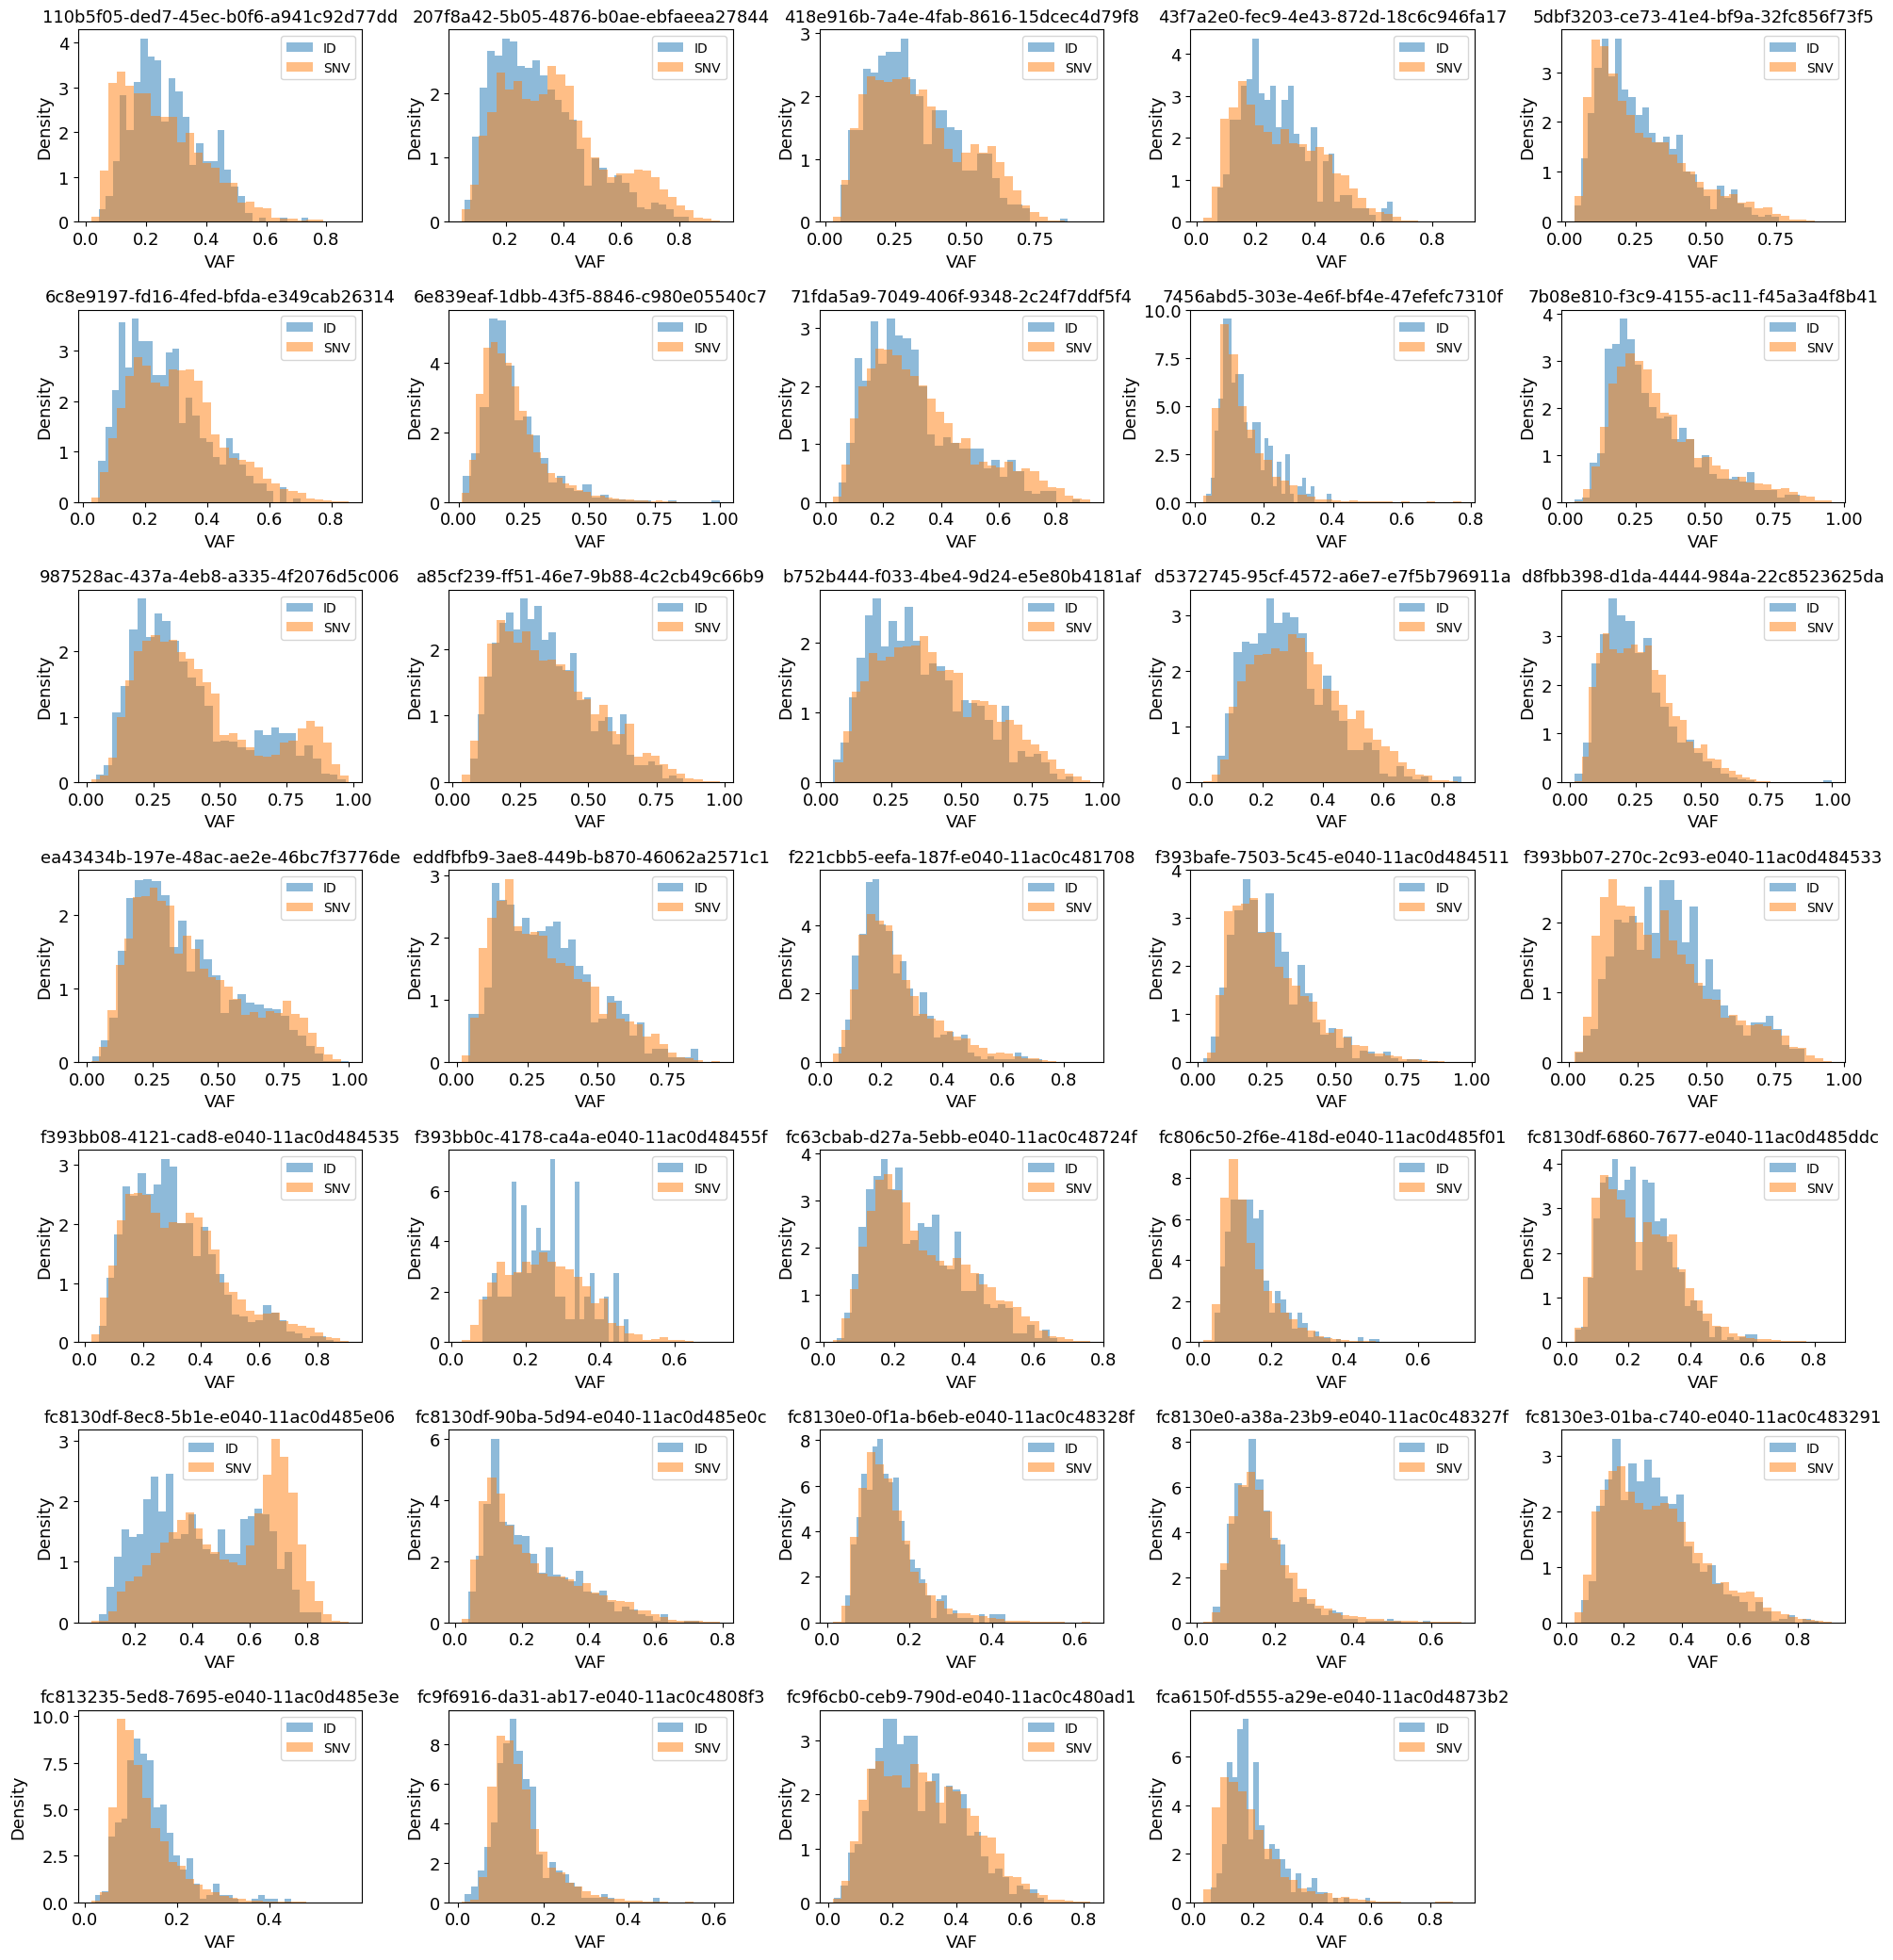

In [ ]:
indel_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_indels"
snv_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_SNVs"

def extract_vaf(info):
    match = re.search(r'VAF=([\d.]+)', info)
    return float(match.group(1)) if match else None

indel_data = {}
for file in os.listdir(indel_dir):
    if file.endswith('.vcf'):
        df = pd.read_csv(os.path.join(indel_dir, file), sep='\t')
        vafs = df['INFO'].apply(extract_vaf).dropna()
        if not vafs.empty:
            indel_data[file.replace('.vcf', '')] = vafs

snv_data = {}
for file in os.listdir(snv_dir):
    if file.endswith('.vcf'):
        df = pd.read_csv(os.path.join(snv_dir, file), sep='\t')
        vafs = df['INFO'].apply(extract_vaf).dropna()
        if not vafs.empty:
            snv_data[file.replace('.vcf', '')] = vafs

samples = sorted(set(indel_data) | set(snv_data))
n_samples = len(samples)
n_cols = 5
n_rows = math.ceil(n_samples / n_cols)

plt.rcParams.update({'font.size': 13, 'pdf.fonttype': 42})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, sample in enumerate(samples):
    ax = axes[i]
    if sample in indel_data:
        ax.hist(indel_data[sample], bins=30, alpha=0.5, label='ID', color='tab:blue', density=True)
    if sample in snv_data:
        ax.hist(snv_data[sample], bins=30, alpha=0.5, label='SNV', color='tab:orange', density=True)
    ax.set_title(sample, fontsize=13)
    ax.set_xlabel('VAF')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


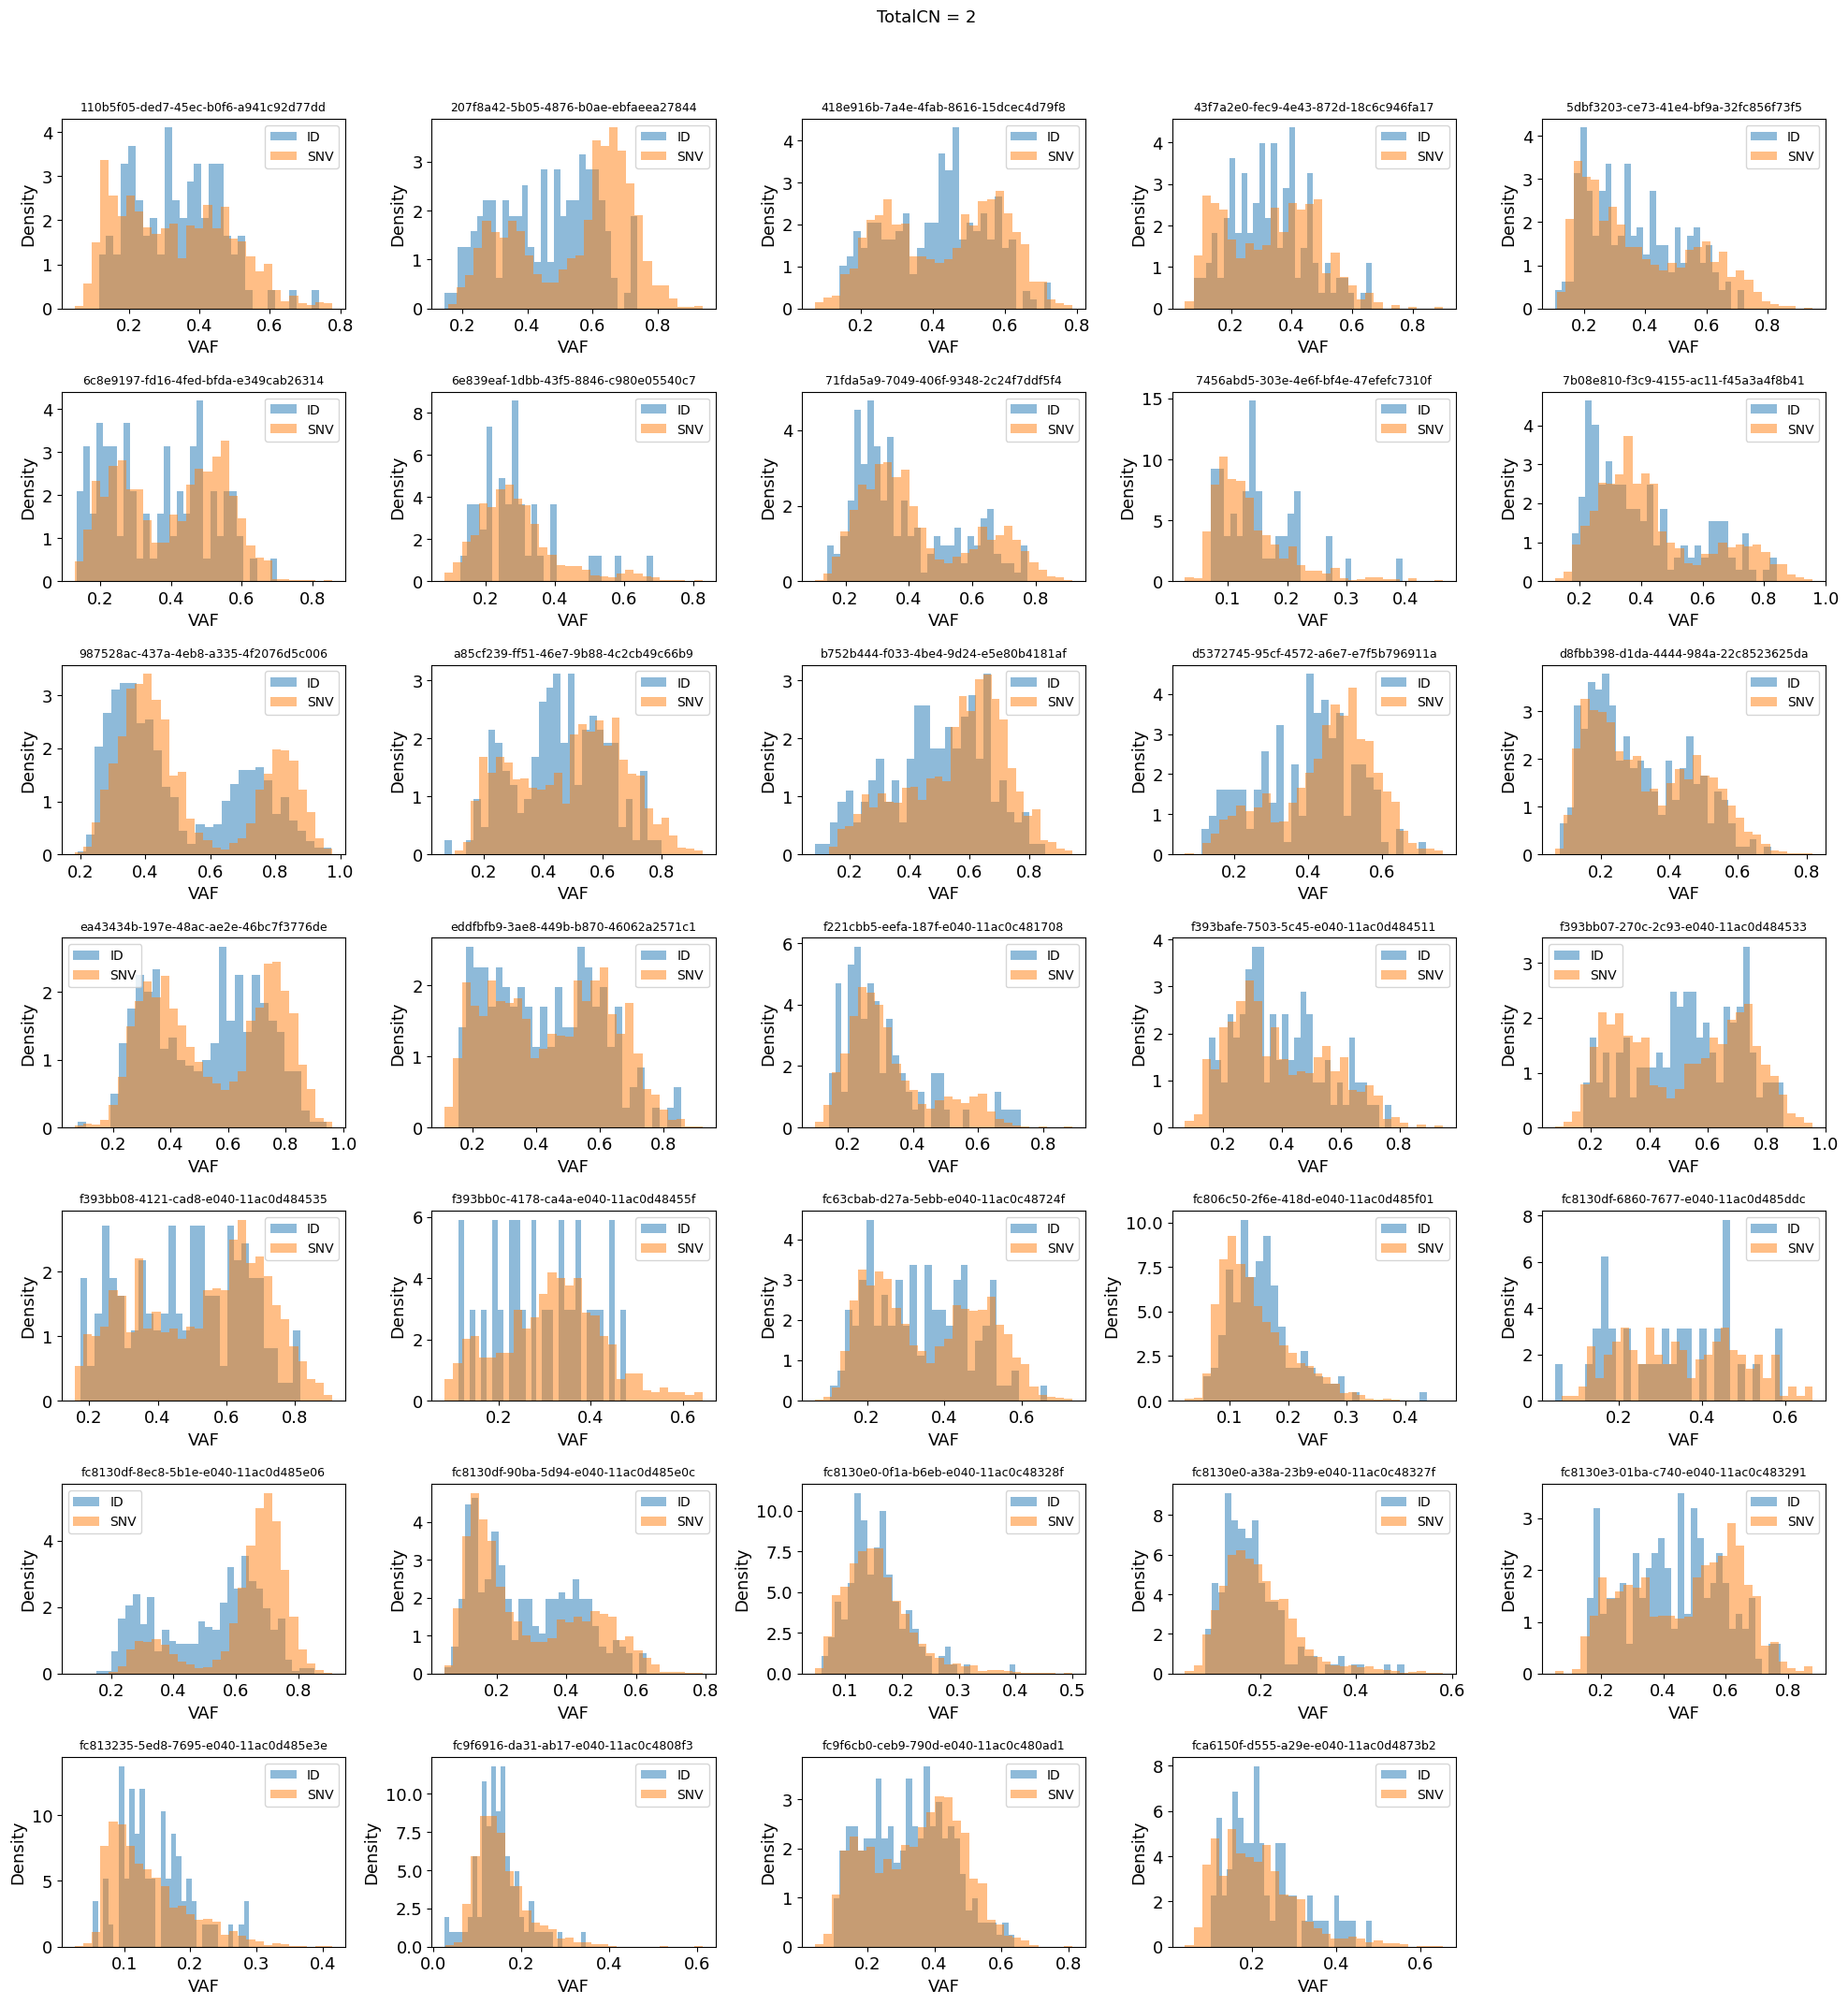

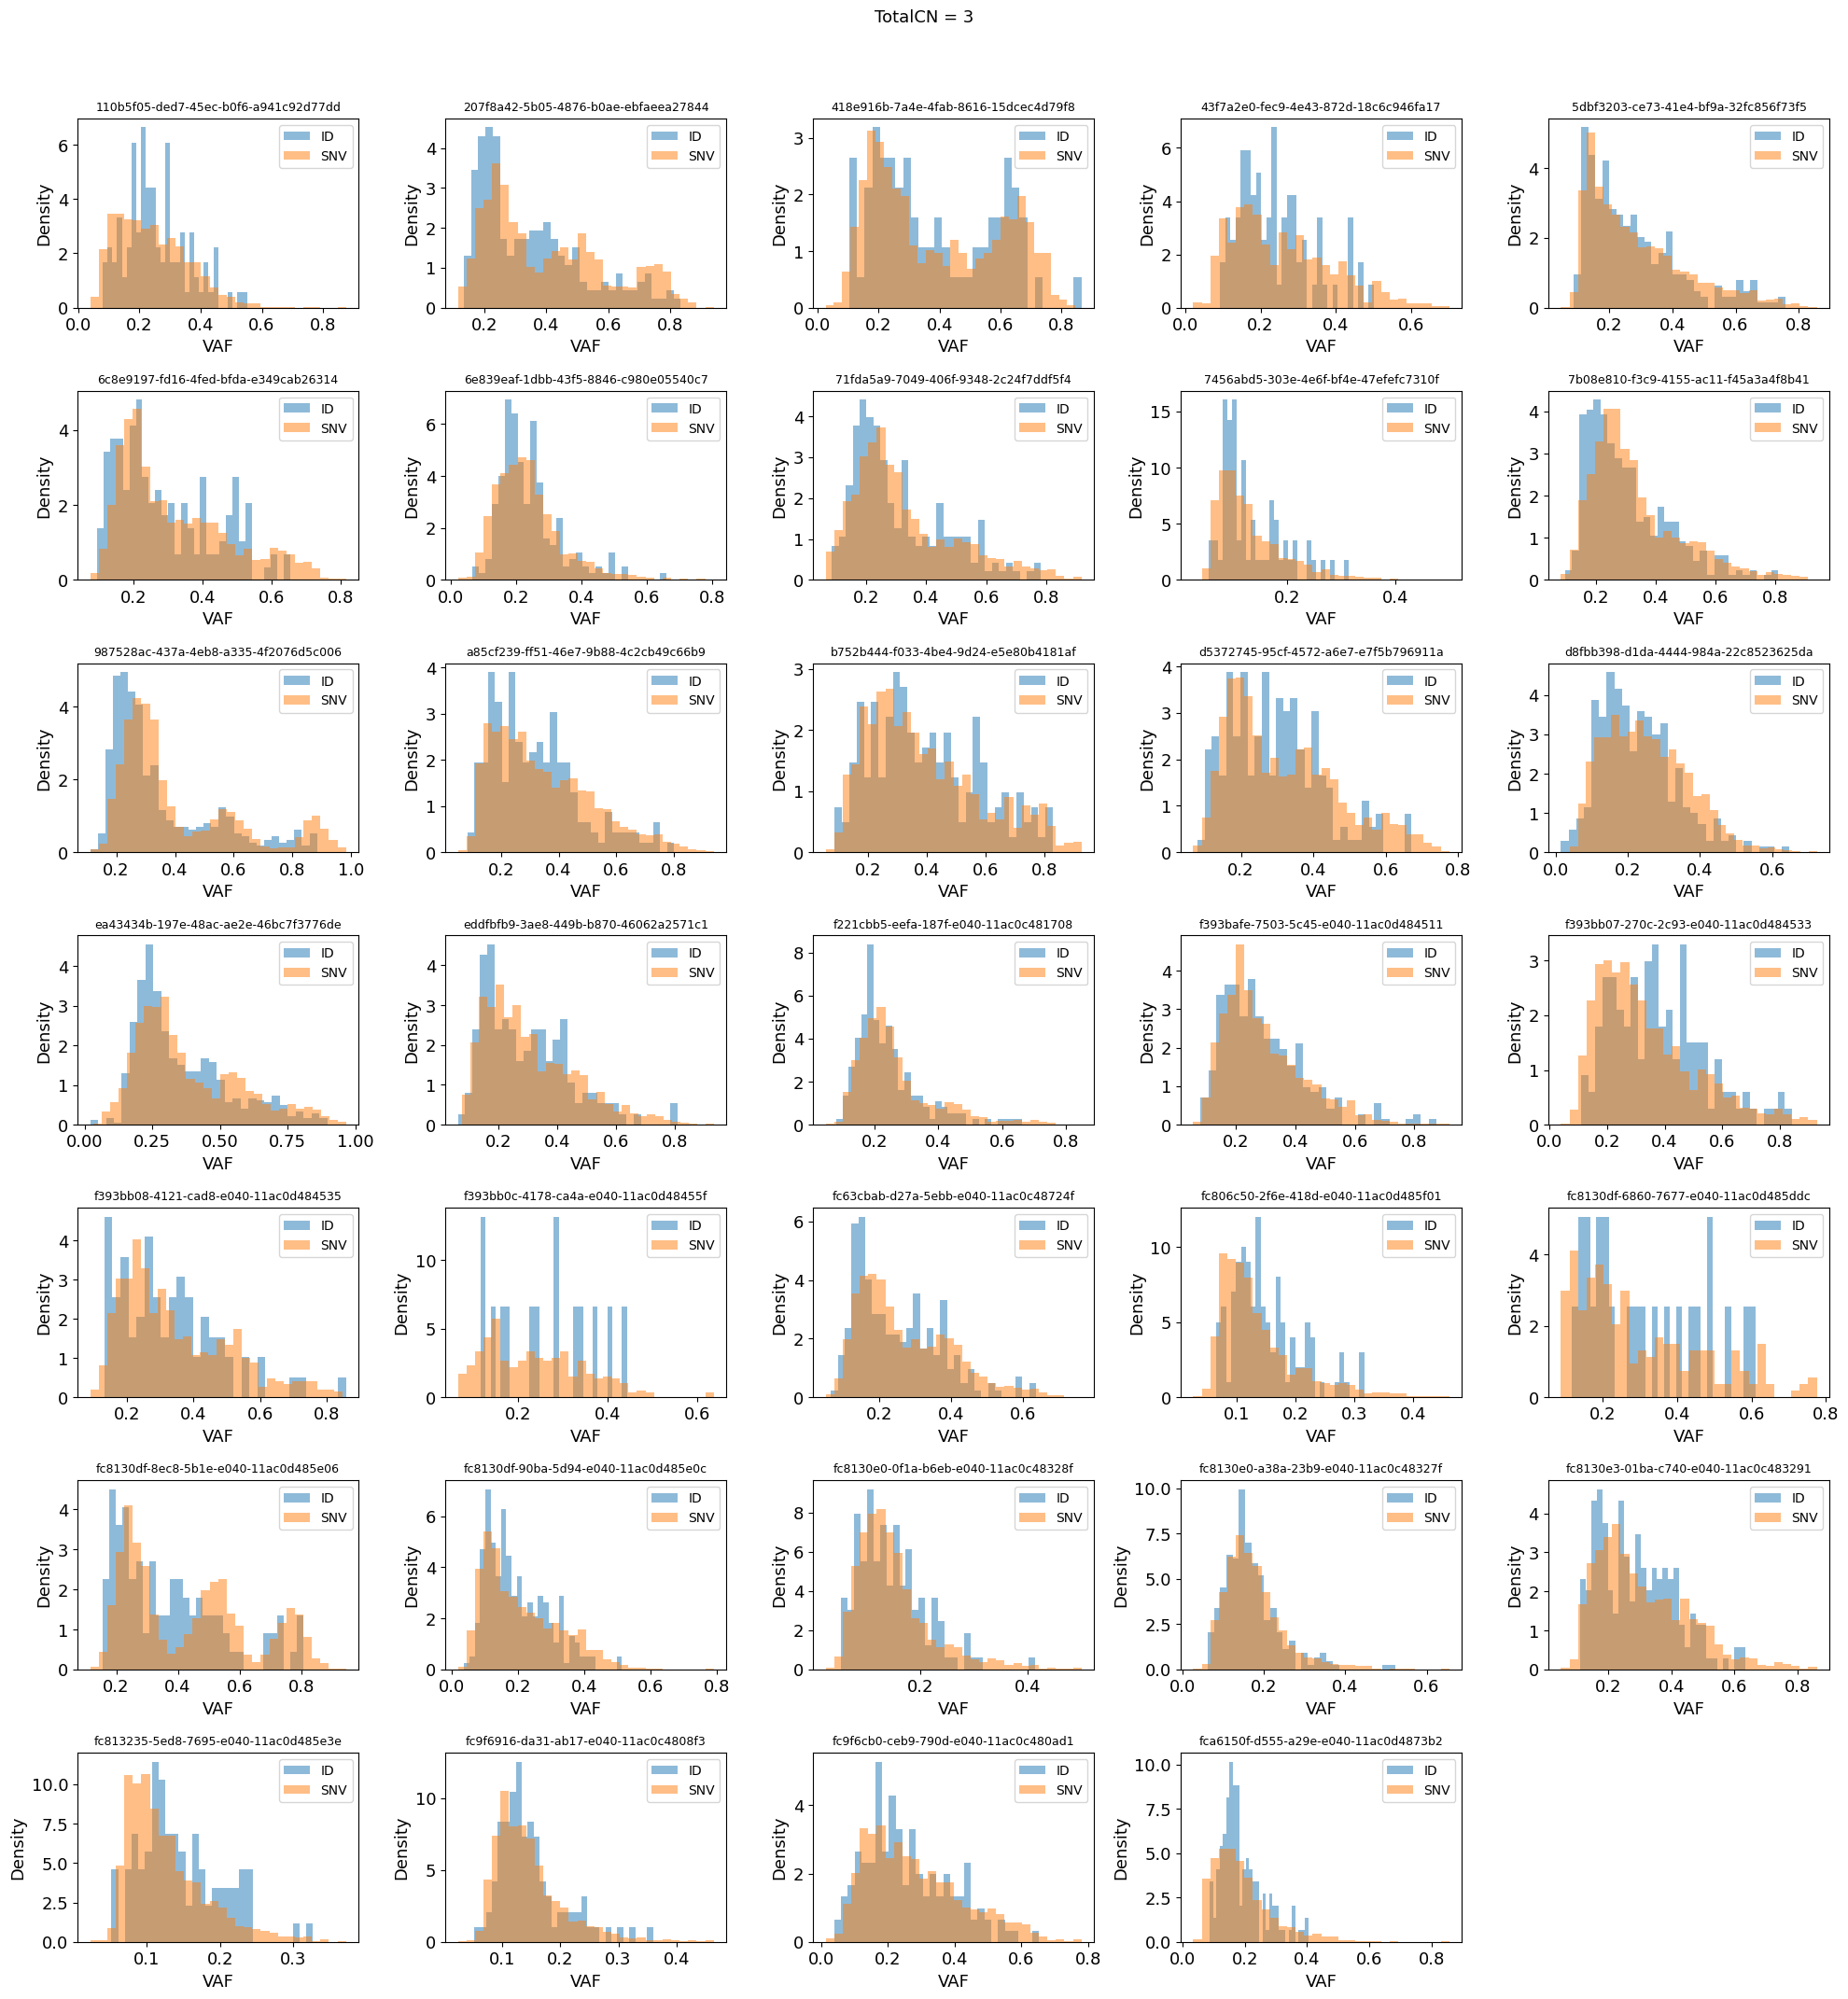

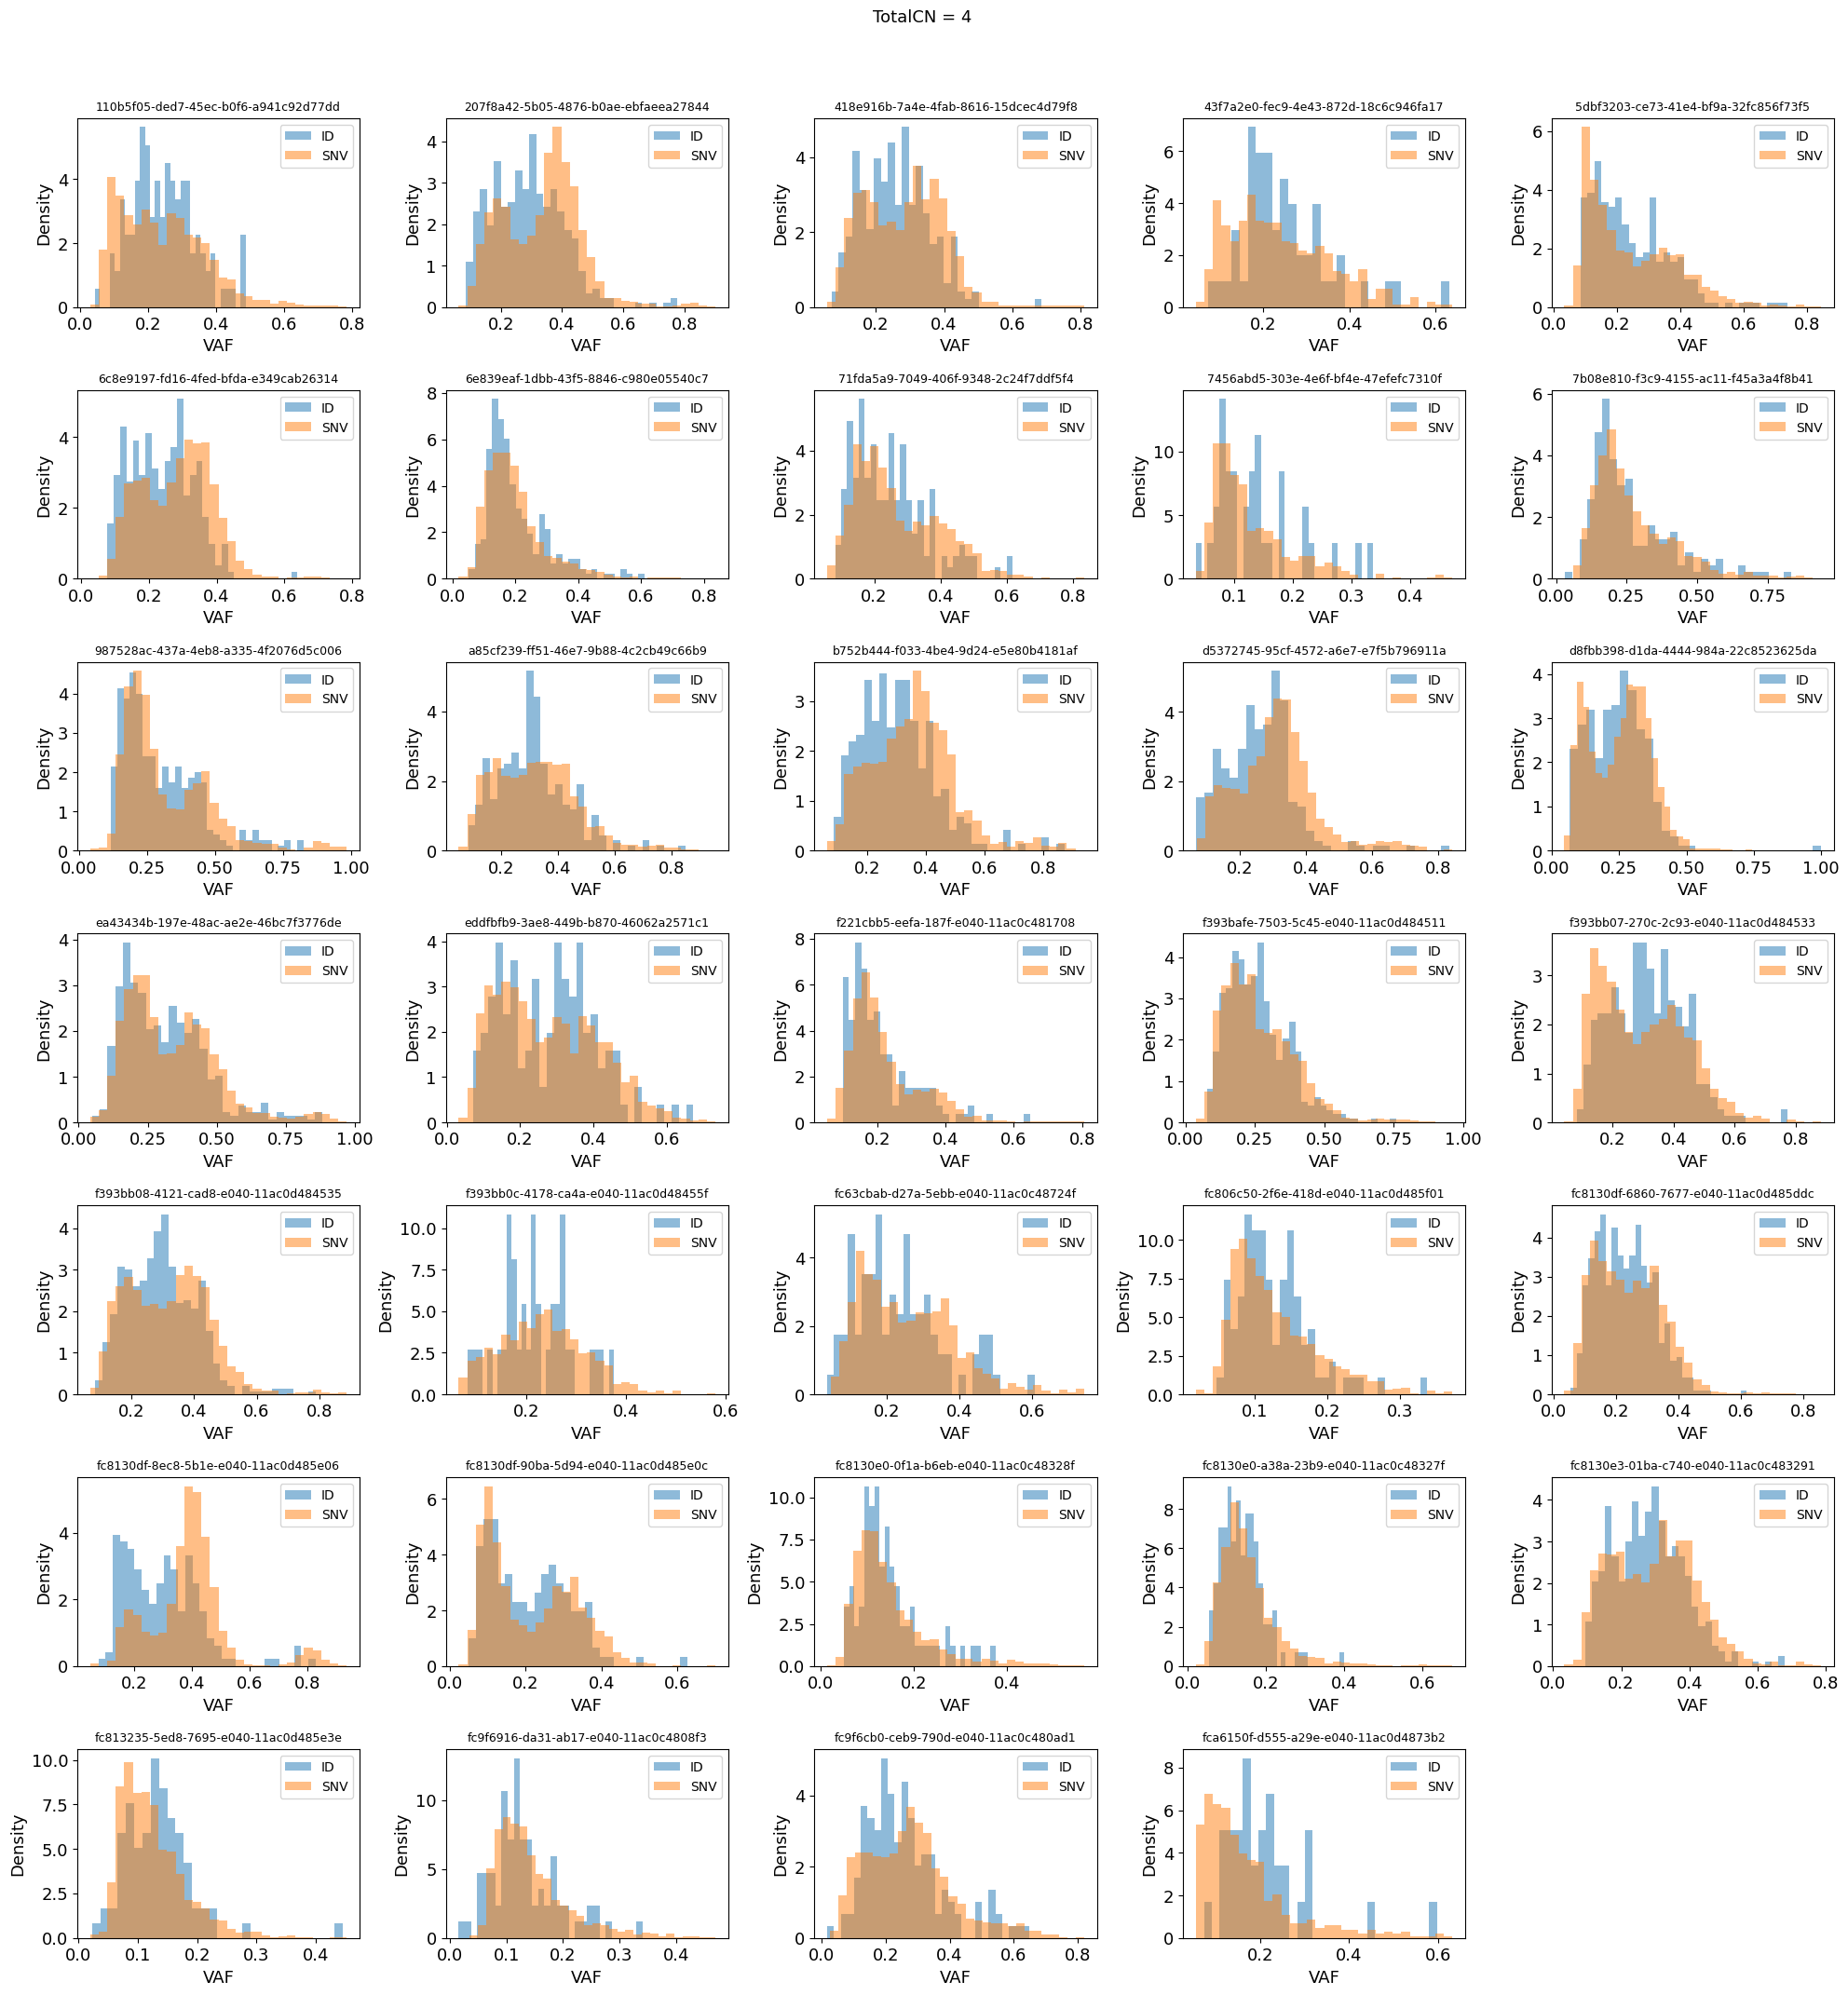

In [ ]:
indel_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_indels"
snv_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_SNVs"

def extract_vaf_and_total_cn(info):
    vaf_match = re.search(r'VAF=([\d.]+)', info)
    mincn_match = re.search(r'MinCN=(\d+)', info)
    majcn_match = re.search(r'MajCN=(\d+)', info)
    
    vaf = float(vaf_match.group(1)) if vaf_match else None
    mincn = int(mincn_match.group(1)) if mincn_match else None
    majcn = int(majcn_match.group(1)) if majcn_match else None
    
    total_cn = (mincn + majcn) if (mincn is not None and majcn is not None) else None
    return vaf, total_cn

def collect_data(folder):
    data = {2: {}, 3: {}, 4: {}}
    for file in os.listdir(folder):
        if file.endswith('.vcf'):
            df = pd.read_csv(os.path.join(folder, file), sep='\t')
            sample_id = file.replace('.vcf', '')
            
            for total_cn in [2, 3, 4]:
                vafs = df['INFO'].apply(lambda x: extract_vaf_and_total_cn(x)) \
                                  .dropna().tolist()
                vafs_for_cn = [v for v, cn in vafs if cn == total_cn and v is not None]
                
                if vafs_for_cn:
                    data[total_cn].setdefault(sample_id, []).extend(vafs_for_cn)
    return data

indel_data = collect_data(indel_dir)
snv_data = collect_data(snv_dir)

for total_cn in [2, 3, 4]:
    samples = sorted(set(indel_data[total_cn]) | set(snv_data[total_cn]))
    n_samples = len(samples)
    n_cols = 5
    n_rows = math.ceil(n_samples / n_cols)
    
    plt.rcParams.update({'font.size': 13, 'pdf.fonttype': 42})
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    
    for i, sample in enumerate(samples):
        ax = axes[i]
        if sample in indel_data[total_cn]:
            ax.hist(indel_data[total_cn][sample], bins=30, alpha=0.5, label='ID', color='tab:blue', density=True)
        if sample in snv_data[total_cn]:
            ax.hist(snv_data[total_cn][sample], bins=30, alpha=0.5, label='SNV', color='tab:orange', density=True)
        ax.set_title(f"{sample}", fontsize=9)
        ax.set_xlabel('VAF')
        ax.set_ylabel('Density')
        ax.legend(fontsize=10)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(f"TotalCN = {total_cn}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


['110b5f05-ded7-45ec-b0f6-a941c92d77dd', '207f8a42-5b05-4876-b0ae-ebfaeea27844', '418e916b-7a4e-4fab-8616-15dcec4d79f8', '43f7a2e0-fec9-4e43-872d-18c6c946fa17', '5dbf3203-ce73-41e4-bf9a-32fc856f73f5', '6c8e9197-fd16-4fed-bfda-e349cab26314', '6e839eaf-1dbb-43f5-8846-c980e05540c7', '71fda5a9-7049-406f-9348-2c24f7ddf5f4', '7456abd5-303e-4e6f-bf4e-47efefc7310f', '7b08e810-f3c9-4155-ac11-f45a3a4f8b41', '987528ac-437a-4eb8-a335-4f2076d5c006', 'a85cf239-ff51-46e7-9b88-4c2cb49c66b9', 'b752b444-f033-4be4-9d24-e5e80b4181af', 'd5372745-95cf-4572-a6e7-e7f5b796911a', 'd8fbb398-d1da-4444-984a-22c8523625da', 'ea43434b-197e-48ac-ae2e-46bc7f3776de', 'eddfbfb9-3ae8-449b-b870-46062a2571c1', 'f221cbb5-eefa-187f-e040-11ac0c481708', 'f393bafe-7503-5c45-e040-11ac0d484511', 'f393bb07-270c-2c93-e040-11ac0d484533', 'f393bb08-4121-cad8-e040-11ac0d484535', 'f393bb0c-4178-ca4a-e040-11ac0d48455f', 'fc63cbab-d27a-5ebb-e040-11ac0c48724f', 'fc806c50-2f6e-418d-e040-11ac0d485f01', 'fc8130df-6860-7677-e040-11ac0d485ddc',

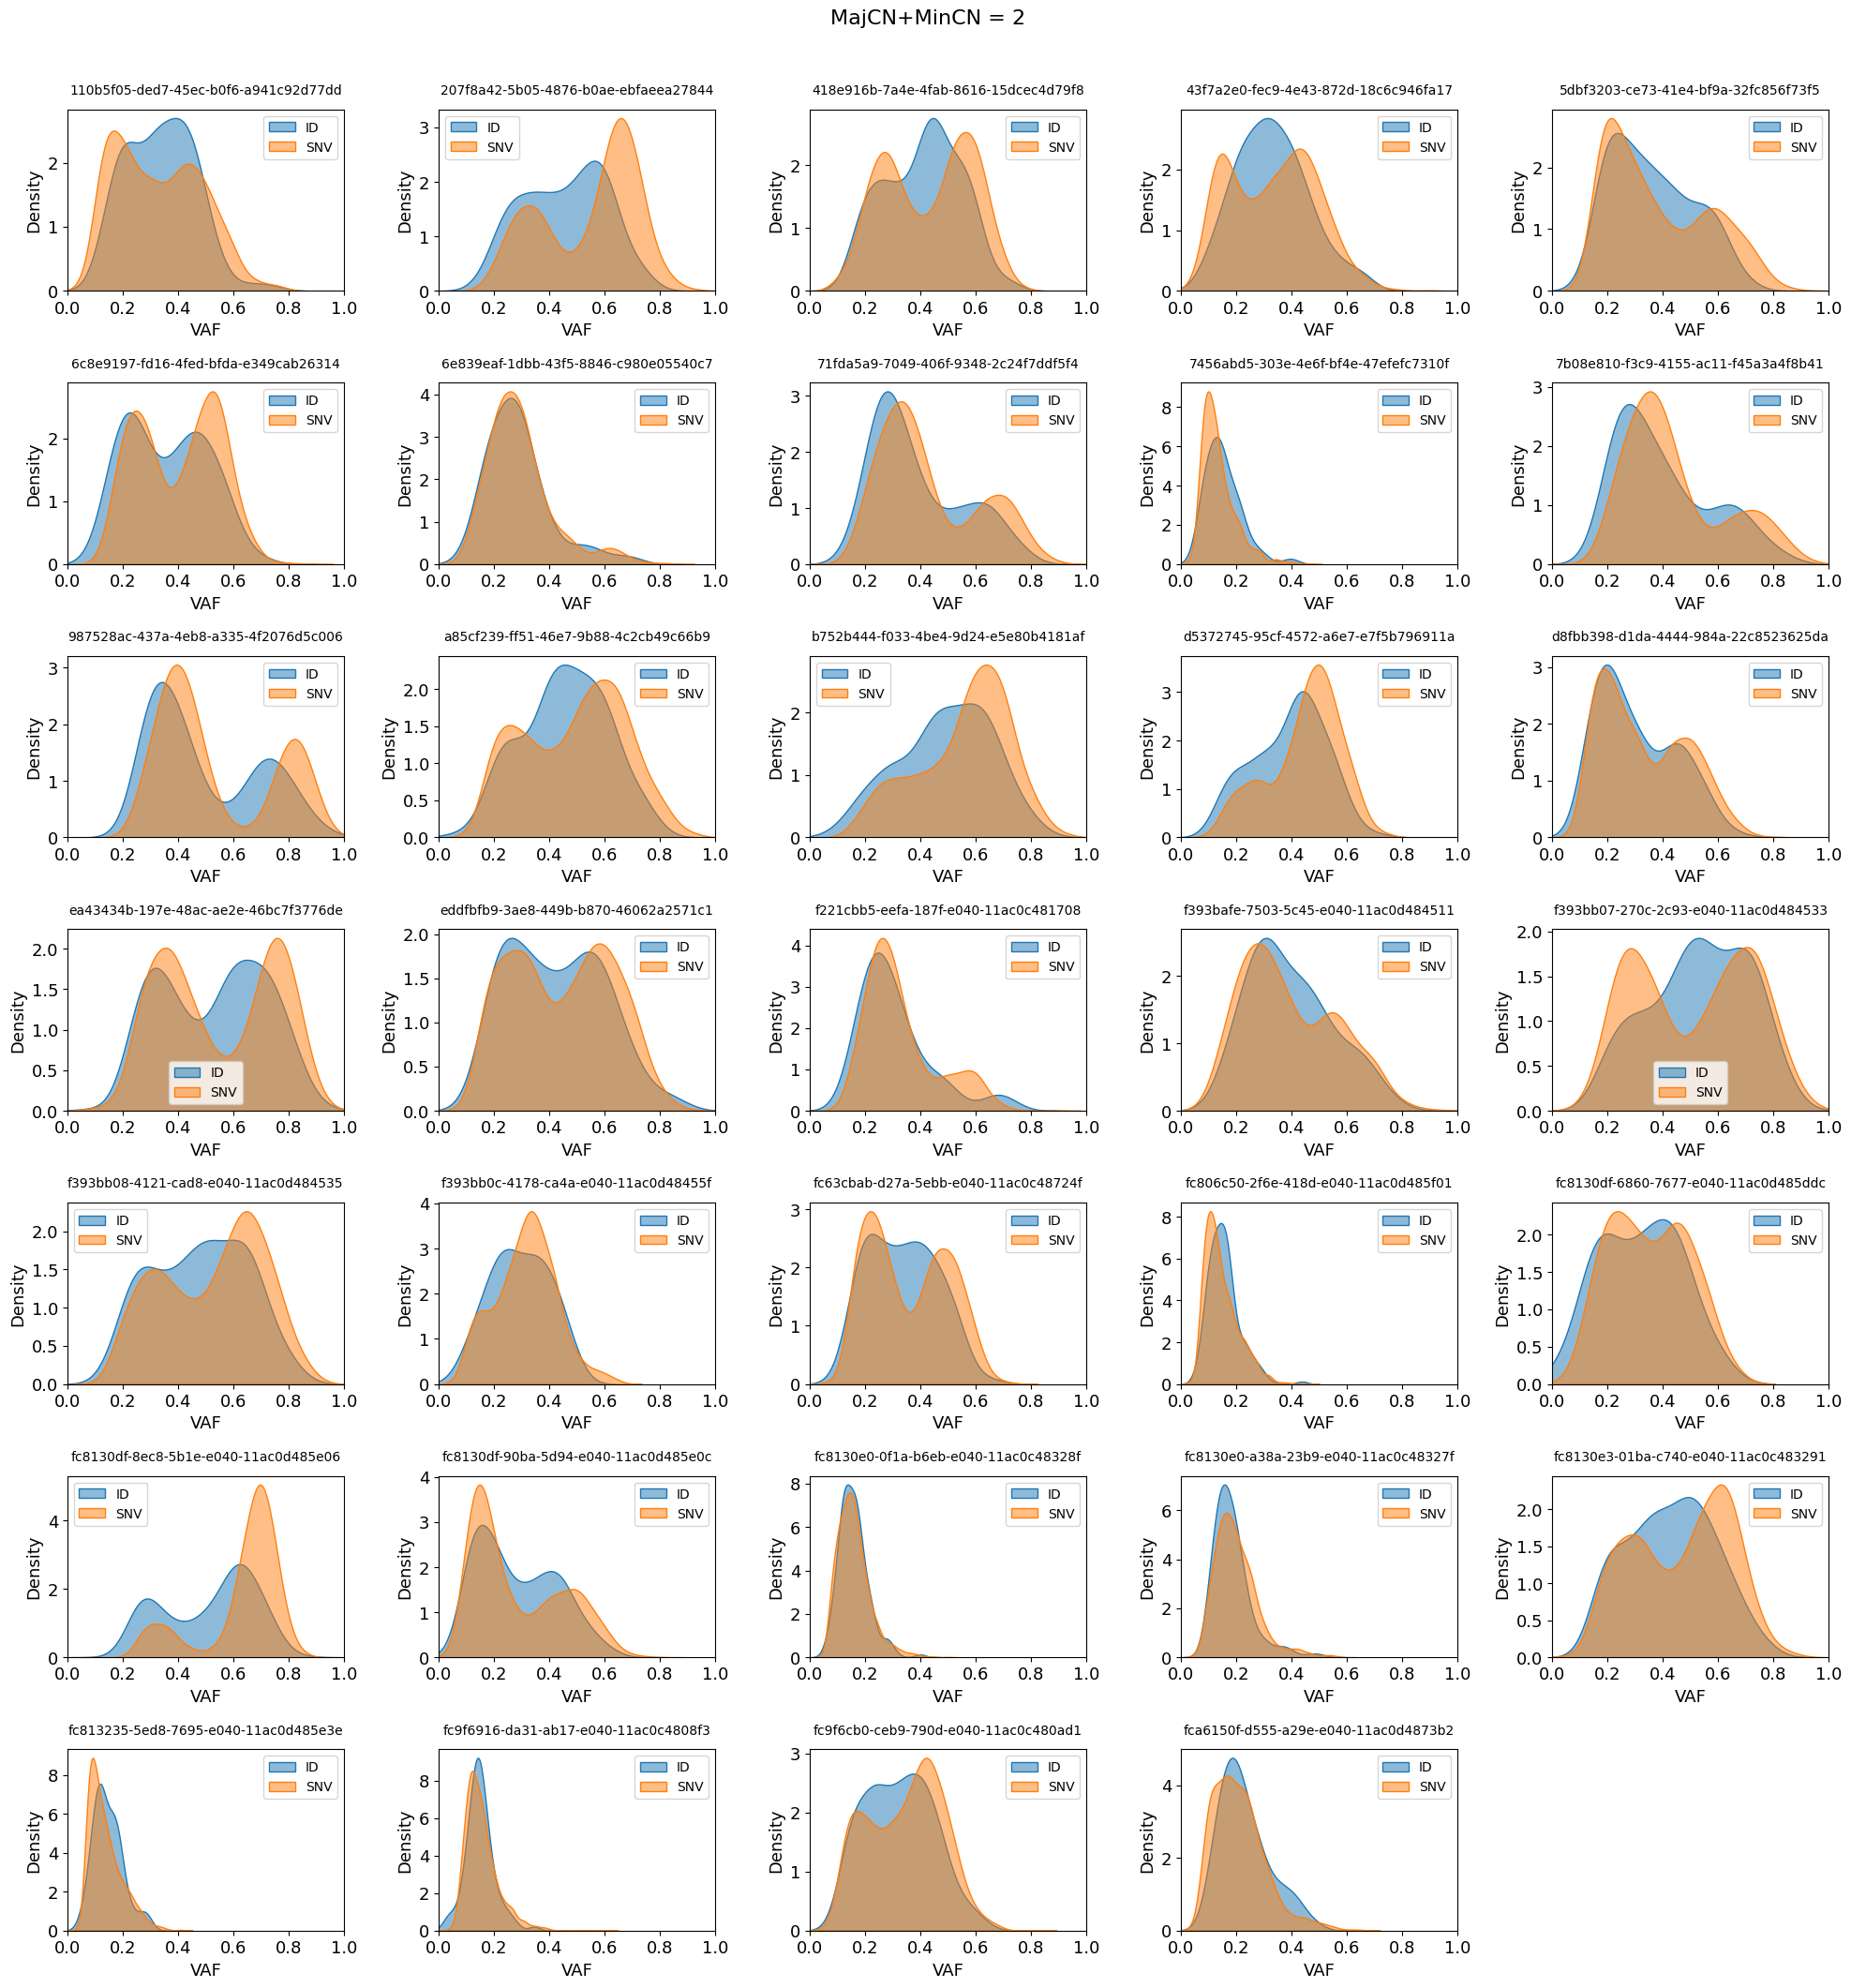

['110b5f05-ded7-45ec-b0f6-a941c92d77dd', '207f8a42-5b05-4876-b0ae-ebfaeea27844', '418e916b-7a4e-4fab-8616-15dcec4d79f8', '43f7a2e0-fec9-4e43-872d-18c6c946fa17', '5dbf3203-ce73-41e4-bf9a-32fc856f73f5', '6c8e9197-fd16-4fed-bfda-e349cab26314', '6e839eaf-1dbb-43f5-8846-c980e05540c7', '71fda5a9-7049-406f-9348-2c24f7ddf5f4', '7456abd5-303e-4e6f-bf4e-47efefc7310f', '7b08e810-f3c9-4155-ac11-f45a3a4f8b41', '987528ac-437a-4eb8-a335-4f2076d5c006', 'a85cf239-ff51-46e7-9b88-4c2cb49c66b9', 'b752b444-f033-4be4-9d24-e5e80b4181af', 'd5372745-95cf-4572-a6e7-e7f5b796911a', 'd8fbb398-d1da-4444-984a-22c8523625da', 'ea43434b-197e-48ac-ae2e-46bc7f3776de', 'eddfbfb9-3ae8-449b-b870-46062a2571c1', 'f221cbb5-eefa-187f-e040-11ac0c481708', 'f393bafe-7503-5c45-e040-11ac0d484511', 'f393bb07-270c-2c93-e040-11ac0d484533', 'f393bb08-4121-cad8-e040-11ac0d484535', 'f393bb0c-4178-ca4a-e040-11ac0d48455f', 'fc63cbab-d27a-5ebb-e040-11ac0c48724f', 'fc806c50-2f6e-418d-e040-11ac0d485f01', 'fc8130df-6860-7677-e040-11ac0d485ddc',

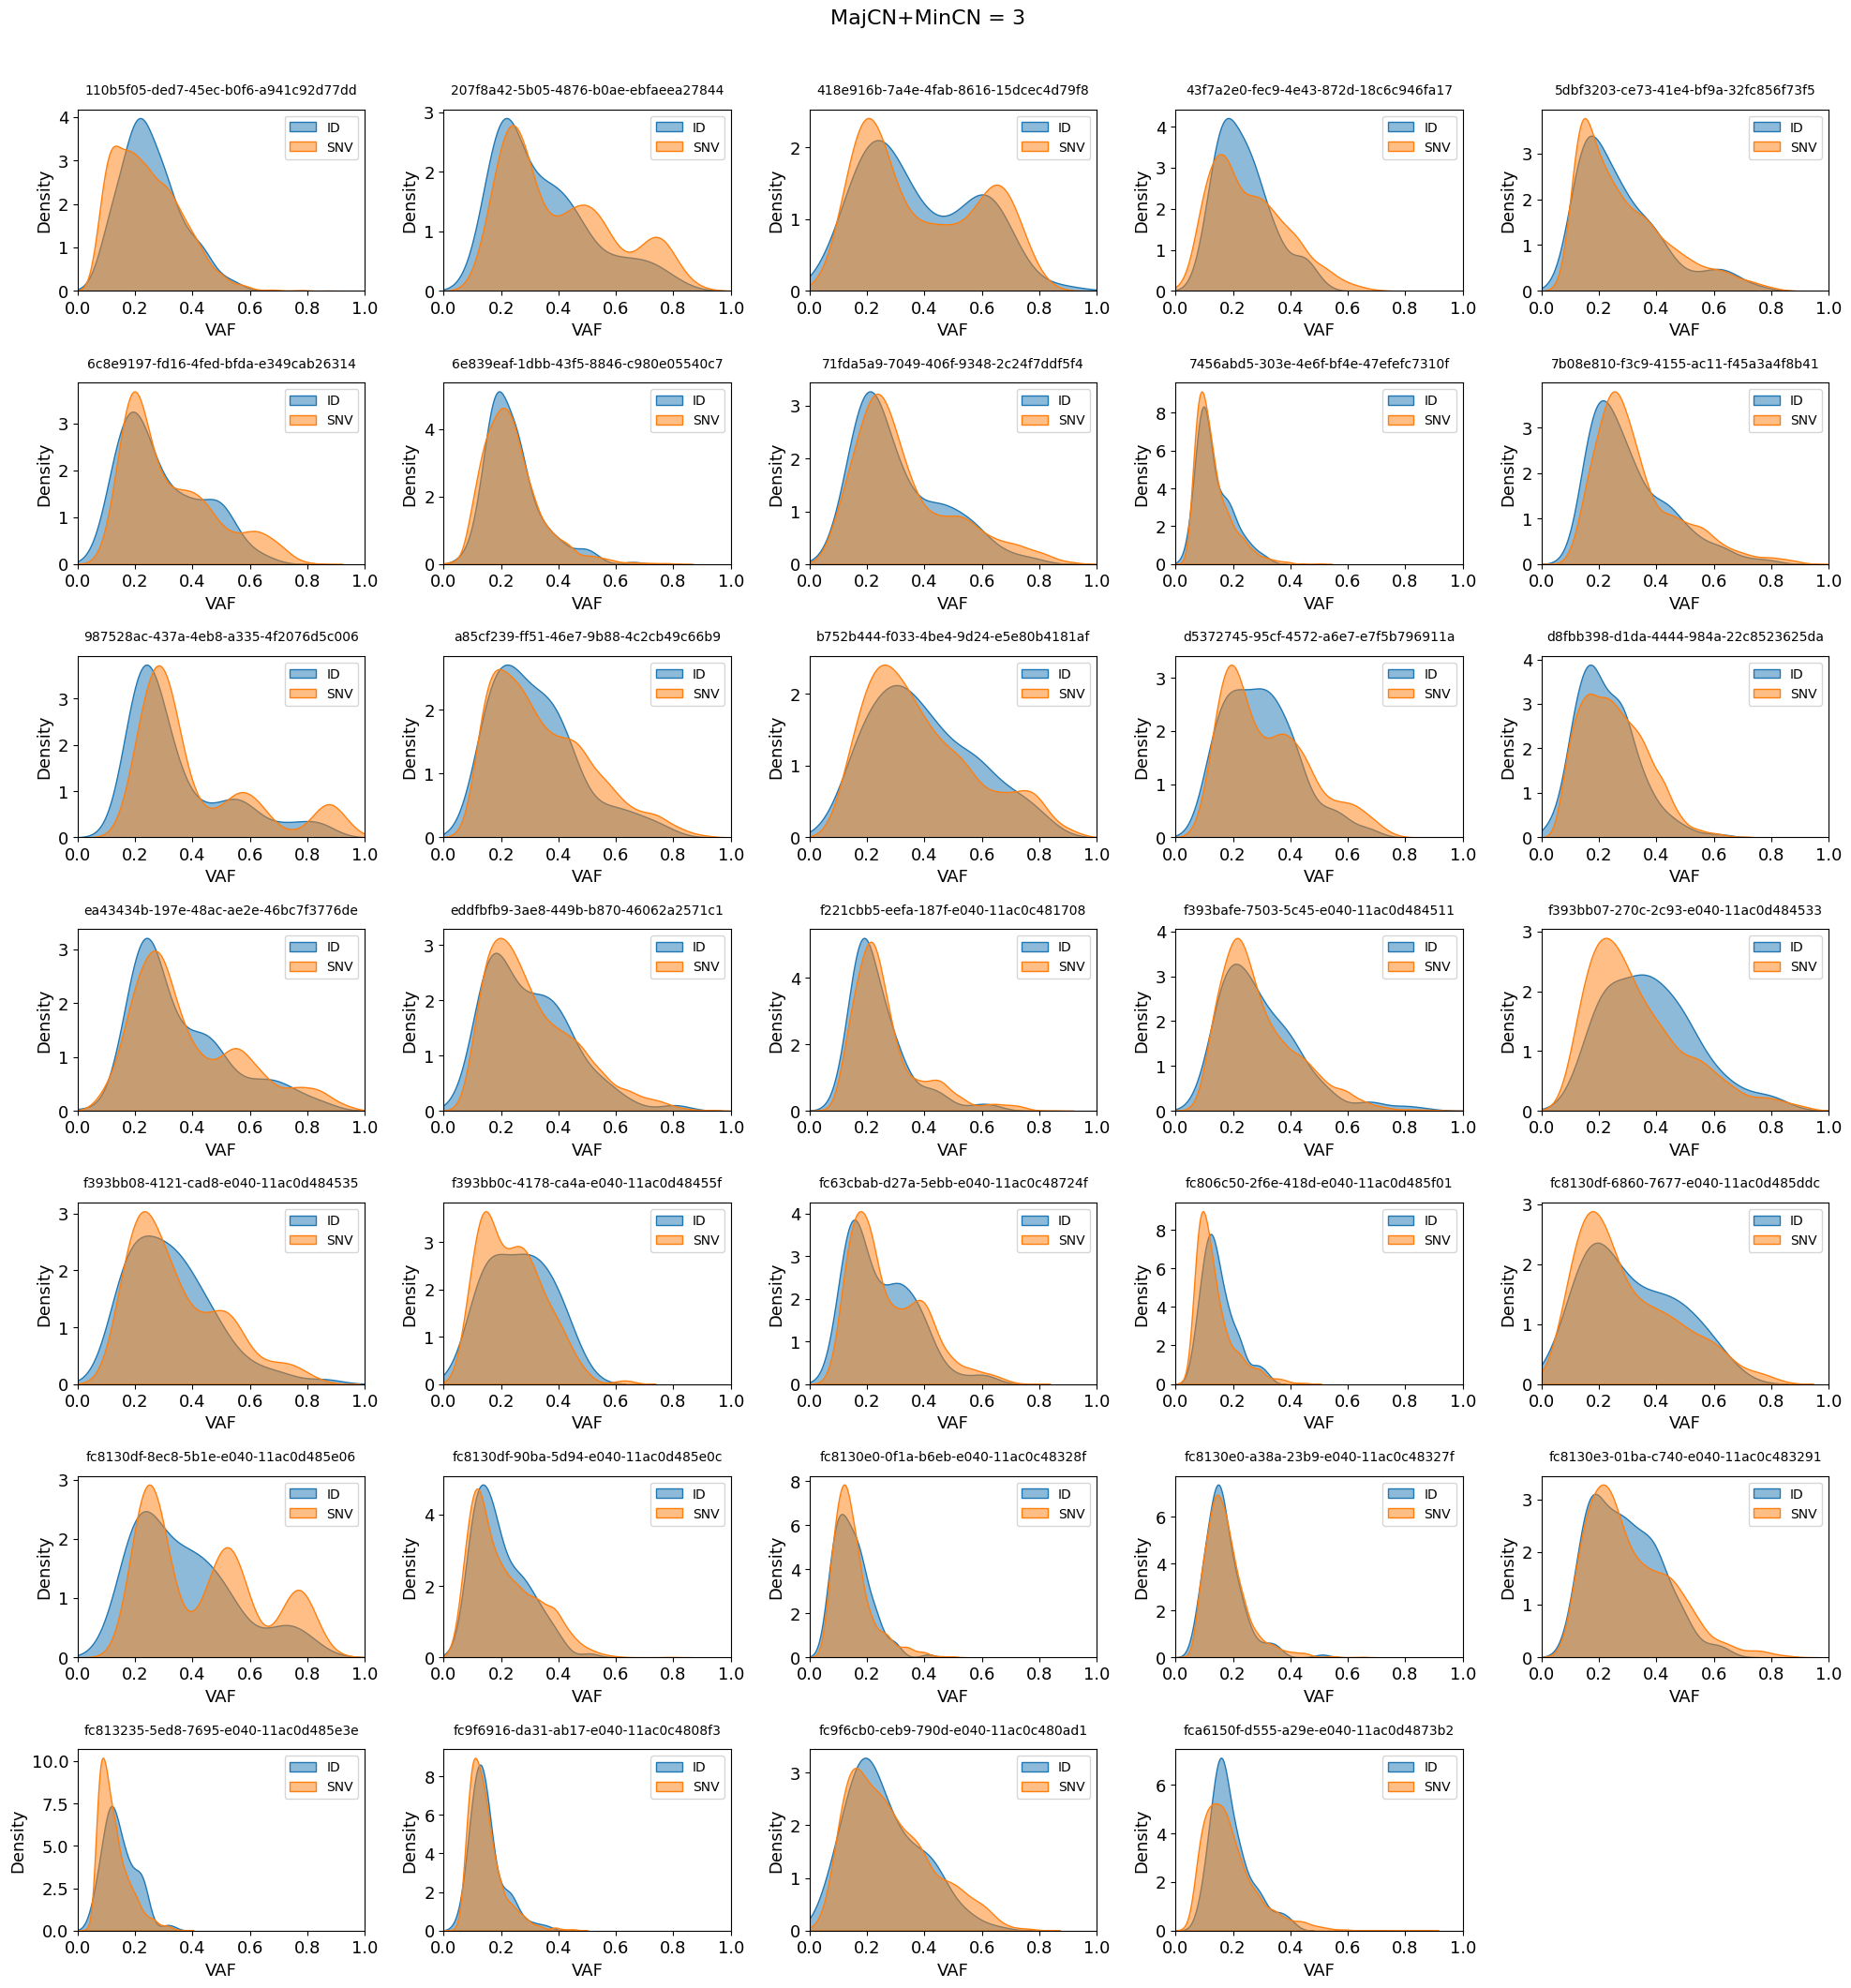

['110b5f05-ded7-45ec-b0f6-a941c92d77dd', '207f8a42-5b05-4876-b0ae-ebfaeea27844', '418e916b-7a4e-4fab-8616-15dcec4d79f8', '43f7a2e0-fec9-4e43-872d-18c6c946fa17', '5dbf3203-ce73-41e4-bf9a-32fc856f73f5', '6c8e9197-fd16-4fed-bfda-e349cab26314', '6e839eaf-1dbb-43f5-8846-c980e05540c7', '71fda5a9-7049-406f-9348-2c24f7ddf5f4', '7456abd5-303e-4e6f-bf4e-47efefc7310f', '7b08e810-f3c9-4155-ac11-f45a3a4f8b41', '987528ac-437a-4eb8-a335-4f2076d5c006', 'a85cf239-ff51-46e7-9b88-4c2cb49c66b9', 'b752b444-f033-4be4-9d24-e5e80b4181af', 'd5372745-95cf-4572-a6e7-e7f5b796911a', 'd8fbb398-d1da-4444-984a-22c8523625da', 'ea43434b-197e-48ac-ae2e-46bc7f3776de', 'eddfbfb9-3ae8-449b-b870-46062a2571c1', 'f221cbb5-eefa-187f-e040-11ac0c481708', 'f393bafe-7503-5c45-e040-11ac0d484511', 'f393bb07-270c-2c93-e040-11ac0d484533', 'f393bb08-4121-cad8-e040-11ac0d484535', 'f393bb0c-4178-ca4a-e040-11ac0d48455f', 'fc63cbab-d27a-5ebb-e040-11ac0c48724f', 'fc806c50-2f6e-418d-e040-11ac0d485f01', 'fc8130df-6860-7677-e040-11ac0d485ddc',

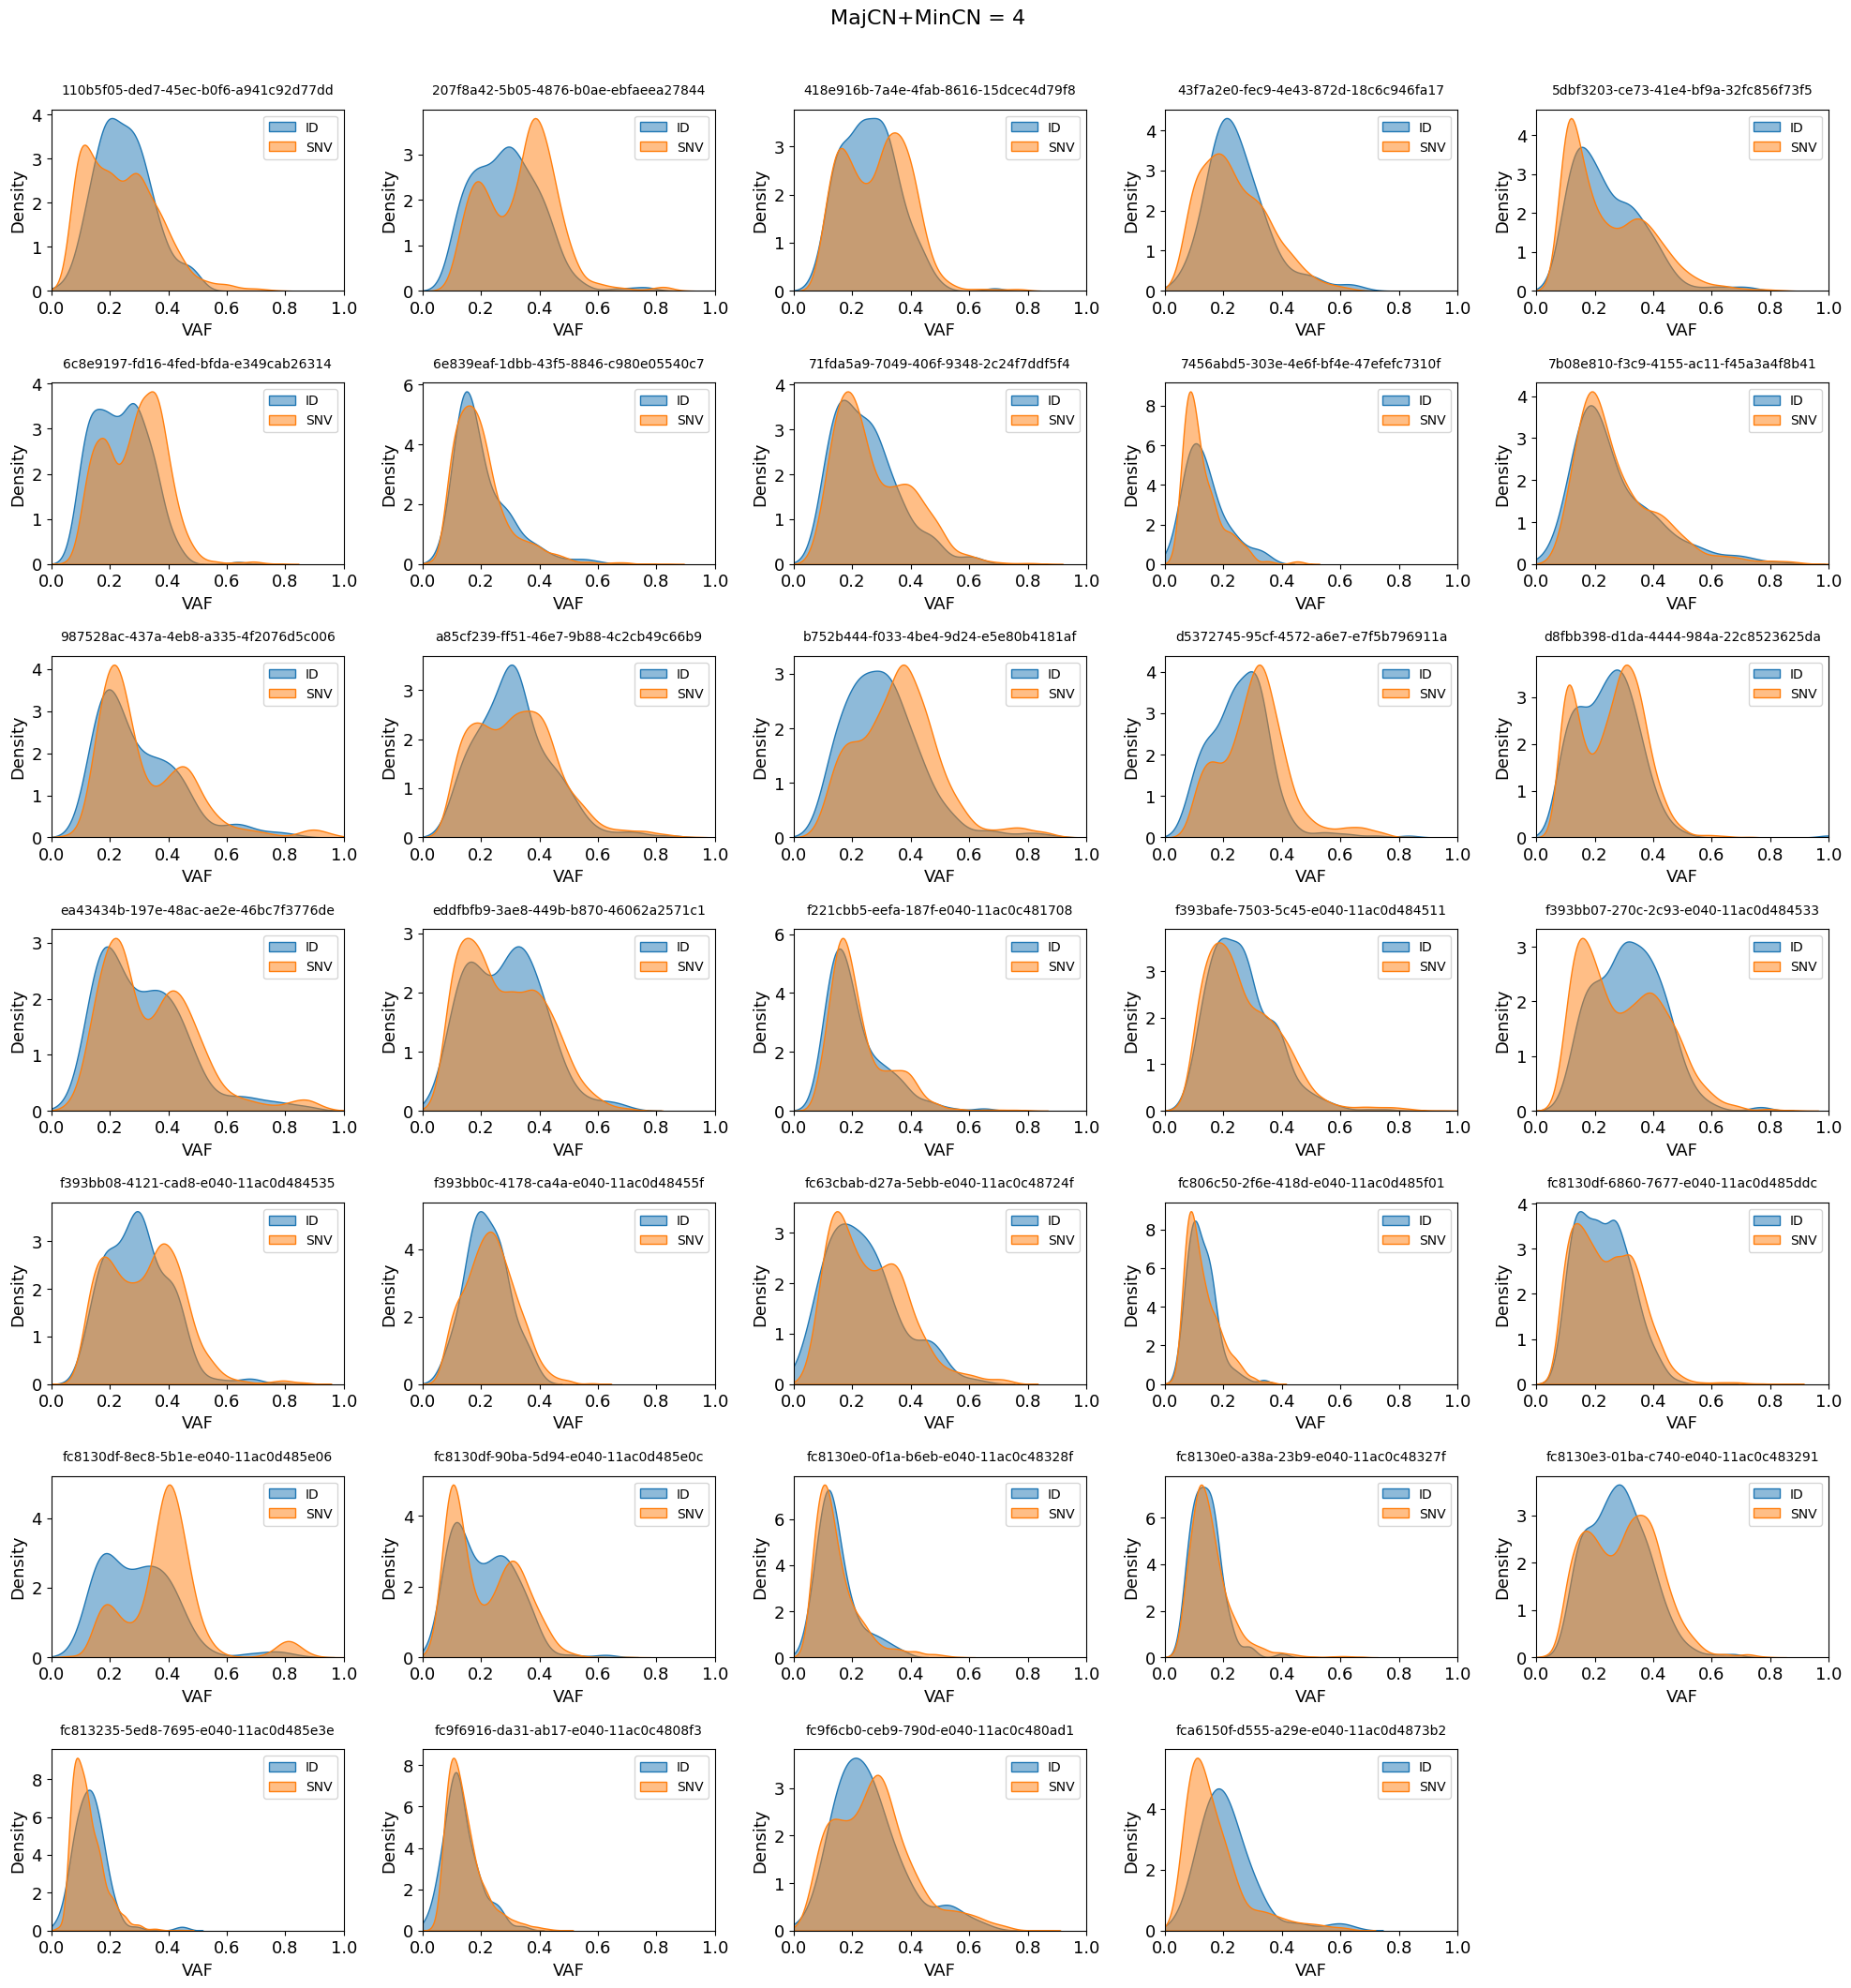

In [ ]:
indel_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_indels"
snv_dir = "../../temp/PCAWG_HRD_WGD_Breast_clonal_SNVs"

def extract_vaf_and_total_cn(info):
    vaf_match = re.search(r'VAF=([\d.]+)', info)
    mincn_match = re.search(r'MinCN=(\d+)', info)
    majcn_match = re.search(r'MajCN=(\d+)', info)
    
    vaf = float(vaf_match.group(1)) if vaf_match else None
    mincn = int(mincn_match.group(1)) if mincn_match else None
    majcn = int(majcn_match.group(1)) if majcn_match else None
    
    total_cn = (mincn + majcn) if (mincn is not None and majcn is not None) else None
    return vaf, total_cn

def collect_data(folder):
    data = {2: {}, 3: {}, 4: {}}
    for file in os.listdir(folder):
        if file.endswith('.vcf'):
            df = pd.read_csv(os.path.join(folder, file), sep='\t')
            sample_id = file.replace('.vcf', '')
            
            vaf_cn_pairs = df['INFO'].apply(lambda x: extract_vaf_and_total_cn(x)).dropna().tolist()
            
            for total_cn in [2, 3, 4]:
                vafs_for_cn = [v for v, cn in vaf_cn_pairs if cn == total_cn and v is not None]
                if vafs_for_cn:
                    data[total_cn].setdefault(sample_id, []).extend(vafs_for_cn)
    return data

indel_data = collect_data(indel_dir)
snv_data = collect_data(snv_dir)

for total_cn in [2, 3, 4]:
    samples = sorted(set(indel_data[total_cn]) | set(snv_data[total_cn]))
    print(samples)
    n_samples = len(samples)
    n_cols = 5
    n_rows = math.ceil(n_samples / n_cols)
    
    plt.rcParams.update({'font.size': 13, 'pdf.fonttype': 42})
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    
    for i, sample in enumerate(samples):
        ax = axes[i]
        if sample in indel_data[total_cn]:
            sns.kdeplot(indel_data[total_cn][sample], ax=ax, label='ID', color='tab:blue', fill=True, alpha=0.5)
        if sample in snv_data[total_cn]:
            sns.kdeplot(snv_data[total_cn][sample], ax=ax, label='SNV', color='tab:orange', fill=True, alpha=0.5)
        ax.set_title(f"{sample}", fontsize=10, y=1.04)
        ax.set_xlabel('VAF')
        ax.set_ylabel('Density')
        ax.legend(fontsize=10)
        ax.set_xlim(0,1)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(f'MajCN+MinCN = {total_cn}', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


## Prepare data for ID signature fitting (using MuSiCal)

In [3]:
# Get ID signatures that are for Breast set according to MuSiCal
catalog = musical.load_catalog('COSMIC_v3p1_Indel')
catalog.restrict_catalog(tumor_type='Breast.AdenoCA', is_MMRD=False, is_PPD=False)
Breast_ID_sigs = catalog.W.columns.tolist()
Musical_Type_vector = catalog.W.index.tolist()

ID_sigs_COSMIC_v3p4 = pd.read_csv("../../data/COSMIC_v3.4_ID_GRCh37 2.txt", sep='\t')
ID_sigs_COSMIC_v3p4 = ID_sigs_COSMIC_v3p4[Breast_ID_sigs]
ID_sigs_COSMIC_v3p4.index = Musical_Type_vector
ID_sigs_COSMIC_v3p4

,ID1,ID2,ID3,ID4,ID5,ID6,ID8,ID9,ID10,ID12,ID17,ID18
DEL.C.1.1,1.598890e-04,0.004824,0.124727,0.007250,0.022202,0.030507,0.039828,3.349399e-01,0.025105,5.278774e-02,6.117599e-03,6.012048e-03
DEL.C.1.2,7.735230e-04,0.000022,0.208876,0.002735,0.028547,0.005492,0.023916,9.999423e-02,0.029306,1.467466e-02,3.667555e-03,2.004016e-03
DEL.C.1.3,3.310000e-18,0.000003,0.176324,0.002041,0.026597,0.008034,0.003331,2.690655e-03,0.018804,5.619320e-04,1.220327e-03,2.004016e-03
DEL.C.1.4,1.907613e-03,0.002472,0.064043,0.001112,0.014159,0.001102,0.005403,1.062542e-02,0.016504,9.955770e-04,2.260000e-08,4.008032e-03
DEL.C.1.5,7.059900e-04,0.003857,0.043990,0.001076,0.002873,0.002478,0.001276,1.249690e-02,0.002931,2.240050e-03,1.940000e-08,1.000000e-18
...,...,...,...,...,...,...,...,...,...,...,...,...
DEL.MH.5+.1,8.160000e-07,0.000625,0.001370,0.000453,0.008617,0.071067,0.280724,3.540000e-05,0.001330,5.633780e-04,2.077133e-02,3.006024e-02
DEL.MH.5+.2,2.380000e-10,0.000118,0.001751,0.000136,0.007851,0.253108,0.123610,2.212360e-04,0.000124,1.420000e-17,1.229006e-02,2.204418e-02
DEL.MH.5+.3,2.330000e-12,0.000057,0.000775,0.001112,0.007158,0.216806,0.046130,5.709070e-04,0.000056,3.235680e-04,8.596258e-03,6.012048e-03
DEL.MH.5+.4,3.880000e-05,0.000463,0.000641,0.003653,0.002493,0.120484,0.016367,4.483080e-04,0.000104,2.776630e-04,4.897913e-03,4.008032e-03


## Create clonal ID mutation matrix

In [ ]:
Analyze.cosmic_fit("../../temp/PCAWG_HRD_WGD_Breast_clonal_indels",
                   "../../temp/PCAWG_HRD_WGD_Breast_clonal_indels" + '/Alexandrov/', 
                   input_type="vcf", context_type="ID",
                   collapse_to_SBS96=False, cosmic_version=3.4, exome=False,
                   genome_build="GRCh37",
                   exclude_signature_subgroups=None, export_probabilities=False,
                   export_probabilities_per_mutation=False, make_plots=False,
                   sample_reconstruction_plots=False, verbose=False)

Starting matrix generation for INDELs...Completed! Elapsed time: 2.44 seconds.
Matrices generated for 34 samples with 0 errors. Total of 0 SNVs, 0 DINUCs, and 25415 INDELs were successfully analyzed.
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 34/34 [100%] in 2.0s (17.41/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


In [5]:
clonal_ID_mutation_matrix = pd.read_csv("../../temp/PCAWG_HRD_WGD_Breast_clonal_indels/output/ID/Input_vcffiles.ID83.all", sep='\t', index_col=0)
clonal_ID_mutation_matrix.index = ID_sigs_COSMIC_v3p4.index
clonal_ID_mutation_matrix 

,110b5f05-ded7-45ec-b0f6-a941c92d77dd,207f8a42-5b05-4876-b0ae-ebfaeea27844,418e916b-7a4e-4fab-8616-15dcec4d79f8,43f7a2e0-fec9-4e43-872d-18c6c946fa17,5dbf3203-ce73-41e4-bf9a-32fc856f73f5,6c8e9197-fd16-4fed-bfda-e349cab26314,6e839eaf-1dbb-43f5-8846-c980e05540c7,71fda5a9-7049-406f-9348-2c24f7ddf5f4,7456abd5-303e-4e6f-bf4e-47efefc7310f,7b08e810-f3c9-4155-ac11-f45a3a4f8b41,...,fc8130df-6860-7677-e040-11ac0d485ddc,fc8130df-8ec8-5b1e-e040-11ac0d485e06,fc8130df-90ba-5d94-e040-11ac0d485e0c,fc8130e0-0f1a-b6eb-e040-11ac0c48328f,fc8130e0-a38a-23b9-e040-11ac0c48327f,fc8130e3-01ba-c740-e040-11ac0c483291,fc813235-5ed8-7695-e040-11ac0d485e3e,fc9f6916-da31-ab17-e040-11ac0c4808f3,fc9f6cb0-ceb9-790d-e040-11ac0c480ad1,fca6150f-d555-a29e-e040-11ac0d4873b2
DEL.C.1.1,24,47,22,10,59,29,37,30,7,27,...,34,77,36,23,23,46,36,18,31,7
DEL.C.1.2,15,26,21,3,31,16,12,11,1,16,...,14,22,10,13,12,14,13,10,14,3
DEL.C.1.3,5,13,9,0,11,11,8,3,2,10,...,7,16,12,2,7,11,3,5,7,2
DEL.C.1.4,1,8,3,0,1,4,5,3,1,5,...,4,4,5,4,6,3,3,2,4,1
DEL.C.1.5,4,3,2,2,3,3,4,3,2,0,...,1,3,3,3,1,2,2,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DEL.MH.5+.1,44,109,23,36,179,56,60,53,5,64,...,72,67,42,37,54,78,53,49,73,10
DEL.MH.5+.2,57,128,46,27,193,88,71,76,13,126,...,123,129,151,45,114,175,57,39,84,6
DEL.MH.5+.3,31,74,30,12,109,60,33,54,5,94,...,112,74,102,48,97,124,23,39,51,2
DEL.MH.5+.4,23,48,21,3,50,37,27,29,7,59,...,61,45,61,30,59,94,15,16,34,6


## Fit Breast ID Signatures

In [6]:
ID_exposures, model_ID = musical.refit.refit(clonal_ID_mutation_matrix, ID_sigs_COSMIC_v3p4, method='likelihood_bidirectional', thresh=0.001)
ID_exposures

,110b5f05-ded7-45ec-b0f6-a941c92d77dd,207f8a42-5b05-4876-b0ae-ebfaeea27844,418e916b-7a4e-4fab-8616-15dcec4d79f8,43f7a2e0-fec9-4e43-872d-18c6c946fa17,5dbf3203-ce73-41e4-bf9a-32fc856f73f5,6c8e9197-fd16-4fed-bfda-e349cab26314,6e839eaf-1dbb-43f5-8846-c980e05540c7,71fda5a9-7049-406f-9348-2c24f7ddf5f4,7456abd5-303e-4e6f-bf4e-47efefc7310f,7b08e810-f3c9-4155-ac11-f45a3a4f8b41,...,fc8130df-6860-7677-e040-11ac0d485ddc,fc8130df-8ec8-5b1e-e040-11ac0d485e06,fc8130df-90ba-5d94-e040-11ac0d485e0c,fc8130e0-0f1a-b6eb-e040-11ac0c48328f,fc8130e0-a38a-23b9-e040-11ac0c48327f,fc8130e3-01ba-c740-e040-11ac0c483291,fc813235-5ed8-7695-e040-11ac0d485e3e,fc9f6916-da31-ab17-e040-11ac0c4808f3,fc9f6cb0-ceb9-790d-e040-11ac0c480ad1,fca6150f-d555-a29e-e040-11ac0d4873b2
ID1,24.376404,30.899430,68.961646,28.620088,17.765432,42.781566,137.057609,52.252782,24.722849,34.308050,...,32.702935,49.574380,42.487492,36.954525,31.821730,62.555296,12.045407,2.572134,23.373841,98.638734
ID2,12.513990,31.272343,96.533170,15.010165,38.053427,34.296580,58.581691,67.339679,10.471890,13.537255,...,11.223117,33.637805,31.656000,12.867795,26.634569,31.990667,10.006118,11.759659,13.540973,27.882250
ID3,22.002452,46.900697,48.531143,0.000000,36.147577,43.281544,21.978178,0.000000,5.170103,33.257252,...,0.000000,37.058438,43.837604,15.657343,24.470263,0.000000,10.649077,16.532997,28.711810,0.000000
ID4,20.154517,114.970865,100.194554,19.591666,47.342967,12.427040,47.346721,33.005160,31.333106,30.905292,...,43.597332,43.444916,24.820009,23.058238,20.960197,26.778364,0.000000,5.194166,14.499314,28.288956
ID5,42.623430,0.000000,48.342413,17.916144,8.956570,30.186971,33.916855,105.864243,33.695089,38.628314,...,53.974043,0.000000,55.847647,29.525897,68.707425,107.474517,0.000000,30.374328,0.000000,33.519776
ID6,155.284173,319.887500,145.640199,23.577755,470.526046,272.478810,178.956158,235.012055,35.173790,438.288213,...,445.355792,376.444301,495.299771,174.244776,414.972525,596.556736,115.881170,122.009651,218.331677,11.050056
ID8,108.563207,297.996210,45.916586,152.047727,447.073062,120.880417,153.356079,124.234231,15.734564,102.898417,...,160.387160,170.235241,85.507574,88.923491,90.346152,150.787284,144.048620,116.743428,196.798172,30.216082
ID9,38.174631,53.500175,24.875529,5.452892,68.103210,26.155695,59.463515,47.234029,0.000000,15.380185,...,33.720270,144.323084,0.000000,34.894105,0.000000,54.255606,69.291893,20.179310,35.802216,13.528921
ID10,0.000000,17.772061,36.156751,6.267995,0.000000,0.000000,0.000000,8.968507,15.730858,0.000000,...,39.809194,16.317240,0.000000,12.611322,11.857010,0.000000,0.000000,0.000000,0.000000,0.000000
ID12,0.000000,12.455929,0.000000,0.000000,0.000000,0.000000,16.255088,0.000000,6.925930,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


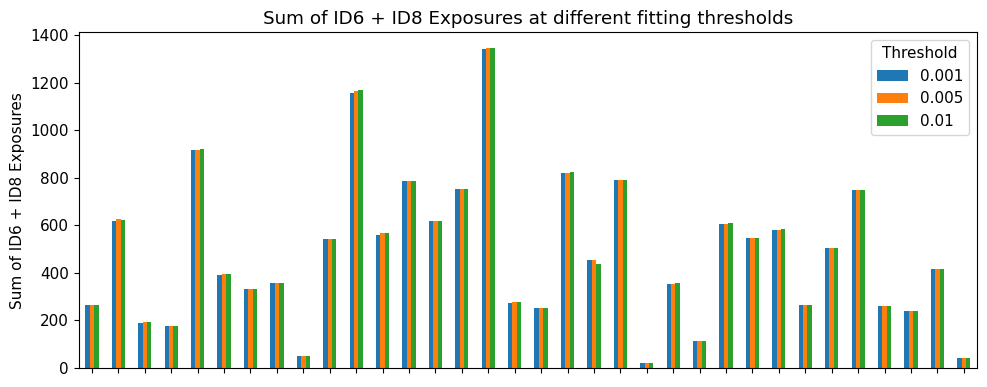

In [57]:
thresholds = [0.001, 0.005, 0.01]
results = {}

for thresh in thresholds:
    ID_exposures, model_ID = musical.refit.refit(
        clonal_ID_mutation_matrix,
        ID_sigs_COSMIC_v3p4,
        method='likelihood_bidirectional',
        thresh=thresh
    )
    sums = ID_exposures.loc[['ID6', 'ID8']].sum(axis=0)
    results[thresh] = sums

plot_df = pd.DataFrame(results)

plt.rcParams.update({'font.size': 11, 'pdf.fonttype': 42})
ax = plot_df.plot(kind='bar', figsize=(10, 4))
ax.set_ylabel('Sum of ID6 + ID8 Exposures')
ax.set_title('Sum of ID6 + ID8 Exposures at different fitting thresholds')
ax.legend(title='Threshold', fontsize=11)
ax.set_xticklabels([])
plt.tight_layout()
plt.show()


## pi1 analysis + VAF plots for samples with low pi1SBS3

In [10]:
from io import StringIO

timing_data = pd.read_csv("../../data/output/All_data_Jun11.csv")
sample_ids = set(timing_data.loc[timing_data['cohort']=='PCAWG','ID'])

id_clonal_dfs = {}
for f in os.listdir("../../temp/PCAWG_HRD_WGD_Breast_clonal_indels"):
    if f.endswith(".vcf") and f[:-4] in sample_ids:
        with open(f"../../temp/PCAWG_HRD_WGD_Breast_clonal_indels/{f}") as fh:
            df = pd.read_csv(StringIO(''.join(l for l in fh if not l.startswith('##'))), sep='\t')
            id_clonal_dfs[f[:-4]] = df

In [7]:
def get_mutation_type_dict(folder_path, mapping):
    dfs = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            if os.path.getsize(file_path) == 0:
                continue
            df = pd.read_csv(file_path, sep='\t', header=None)
            df.columns = ['Sample', '#CHROM', 'POS', 'Mutation', 'REF', 'ALT', 'Strand']
            df['#CHROM'] = df['#CHROM'].astype(str).str.replace('chr', '', regex=False)
            df['MutationType_COSMIC'] = df['Mutation'].str[2:11]
            df['MutationType_MuSiCal'] = df['MutationType_COSMIC'].map(mapping)
            dfs.append(df)
    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        grouped = {
            sample: group.drop(columns='Sample').reset_index(drop=True)
            for sample, group in combined.groupby('Sample')
        }
        return grouped
    return {}

def append_signature_probabilities(sample_df, sample_name, H_reduced_normalized, W_reduced):
    if sample_name not in H_reduced_normalized.columns:
        return sample_df
    weights = H_reduced_normalized[sample_name]
    weighted = W_reduced.multiply(weights, axis=1)
    probs = weighted.div(weighted.sum(axis=1), axis=0)
    for signature in probs.columns:
        prob_map = probs[signature]
        sample_df[f'prob_{signature}'] = sample_df['MutationType_MuSiCal'].map(prob_map)
    return sample_df

COSMIC_ID_83 = pd.read_csv(
    '../../temp/PCAWG_HRD_WGD_Breast_clonal_indels/output/ID/Input_vcffiles.ID83.all',
    sep='\t'
)['MutationType']
MUSICAL_ID_83 = ID_sigs_COSMIC_v3p4.index
mapping = dict(zip(COSMIC_ID_83, MUSICAL_ID_83))

mut_dict = get_mutation_type_dict(
    '../../temp/PCAWG_HRD_WGD_Breast_clonal_indels/output/vcf_files/ID',
    mapping
)

mut_dict = {
    sample: append_signature_probabilities(df, sample, model_ID.H_reduced_normalized, model_ID.W_reduced)
    for sample, df in mut_dict.items()
}

In [11]:
sig_annotated_clonal_id = {
    sample: pd.merge(
        mut_df,
        id_clonal_dfs[sample],
        on=['#CHROM', 'POS', 'REF', 'ALT'],
        how='inner'
    )
    for sample, mut_df in mut_dict.items()
    if sample in id_clonal_dfs
}

fields = ['MajCN', 'MinCN', 'MutCN', 'pSingle', 'pGain']

def extract_info_fields(df):
    for field in fields:
        df[field] = df['INFO'].str.extract(fr'{field}=([^;]+)').astype(float)
    return df

sig_annotated_clonal_id = {sample: extract_info_fields(df) for sample, df in sig_annotated_clonal_id.items()}

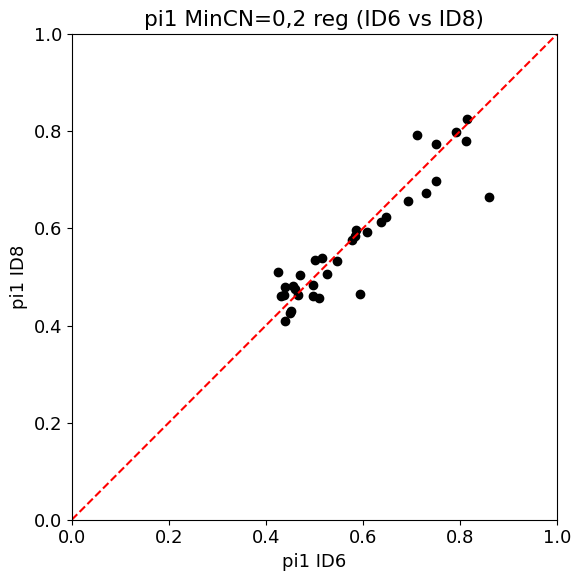

In [12]:
pi2_ID8_results_dict = {}
minCN_counts_dict = {}

for sample_id, df in sig_annotated_clonal_id.items():
    pi_2_ID8 = {0: np.nan, 1: np.nan, 2: np.nan}
    minCN_counts = {}

    for min_cn in [0, 1, 2]:
        subset = df[df['MinCN'] == min_cn]
        minCN_counts[min_cn] = len(subset)

        sum_num_ID8 = 0
        sum_pi_ID8 = 0

        for _, row in subset.iterrows():
            prob_id8 = row['prob_ID8']
            p_gain = row['pGain']
            p_single = row['pSingle']

            if (p_single + p_gain) != 0:
                sum_num_ID8 += prob_id8 * p_single
            sum_pi_ID8 += prob_id8

        pi_2_ID8[min_cn] = sum_num_ID8 / sum_pi_ID8 if sum_pi_ID8 != 0 else np.nan

    pi2_ID8_results_dict[sample_id] = pi_2_ID8
    minCN_counts_dict[sample_id] = minCN_counts

# Compute pi2_ID6_results_dict
pi2_ID6_results_dict = {}
for key, df in sig_annotated_clonal_id.items():
    pi2_ID6 = {0: np.nan, 1: np.nan, 2: np.nan}
    for min_cn in [0, 1, 2]:
        subsample = df[df['MinCN'] == min_cn]
        sum_num = 0
        sum_pi = 0
        for _, row in subsample.iterrows():
            prob_id6 = row['prob_ID6']
            p_gain = row['pGain']
            p_single = row['pSingle']
            sum_num += prob_id6 * p_single
            sum_pi += prob_id6
        pi2_ID6[min_cn] = sum_num / sum_pi if sum_pi != 0 else np.nan
    pi2_ID6_results_dict[key] = pi2_ID6

# Compute weighted averages
weighted_pi2_ID6 = {}
weighted_pi2_ID8 = {}

for sample in pi2_ID8_results_dict.keys():
    pi2_0_ID8 = pi2_ID8_results_dict[sample].get(0, np.nan)
    pi2_2_ID8 = pi2_ID8_results_dict[sample].get(2, np.nan)
    pi2_0_ID6 = pi2_ID6_results_dict[sample].get(0, np.nan)
    pi2_2_ID6 = pi2_ID6_results_dict[sample].get(2, np.nan)

    n0 = minCN_counts_dict[sample].get(0, 0)
    n2 = minCN_counts_dict[sample].get(2, 0)
    total = n0 + n2

    if total > 0:
        if not pd.isna(pi2_0_ID8) and not pd.isna(pi2_2_ID8):
            weighted_pi2_ID8[sample] = (pi2_0_ID8 * n0 + pi2_2_ID8 * n2) / total
        else:
            weighted_pi2_ID8[sample] = np.nan

        if not pd.isna(pi2_0_ID6) and not pd.isna(pi2_2_ID6):
            weighted_pi2_ID6[sample] = (pi2_0_ID6 * n0 + pi2_2_ID6 * n2) / total
        else:
            weighted_pi2_ID6[sample] = np.nan
    else:
        weighted_pi2_ID8[sample] = np.nan
        weighted_pi2_ID6[sample] = np.nan

# Plot
df_corr = pd.DataFrame({
    'pi2_ID6_weighted': pd.Series(weighted_pi2_ID6),
    'pi2_ID8_weighted': pd.Series(weighted_pi2_ID8)
}).dropna()

plt.figure(figsize=(6, 6))
plt.rcParams.update({'font.size': 13, 'pdf.fonttype': 42})
plt.scatter(df_corr['pi2_ID6_weighted'], df_corr['pi2_ID8_weighted'], alpha=1, color='k')
plt.plot([0,1], [0,1], 'r--')
plt.ylim(0,1)
plt.xlim(0,1)
plt.xlabel('pi1 ID6')
plt.ylabel('pi1 ID8')
plt.title('pi1 MinCN=0,2 reg (ID6 vs ID8)')
plt.tight_layout()
plt.show()


Pearson correlation coefficient (r): 0.9077
Pearson correlation p-value: 1.298e-13


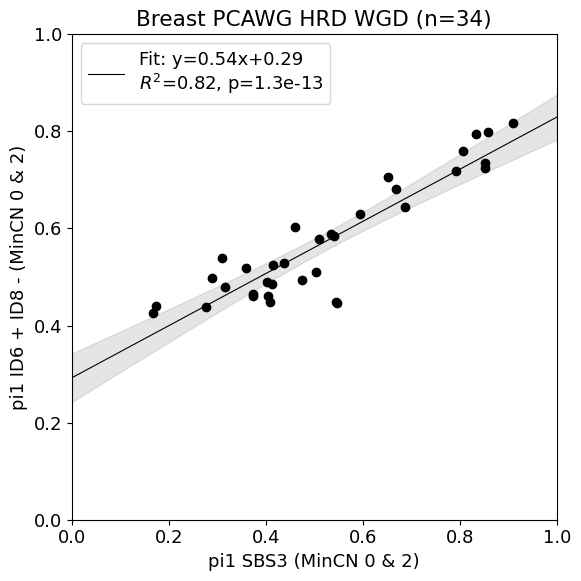

In [15]:
import pandas as pd, numpy as np, ast, matplotlib.pyplot as plt, statsmodels.api as sm
from scipy.stats import pearsonr  # <-- Add this

# Compute combined_pi2_results & minCN_counts_dict
combined_pi2_results, minCN_counts_dict = {}, {}
for sid, df in sig_annotated_clonal_id.items():
    combined_pi2 = {}
    minCN_counts = {cn: len(df[df['MinCN'] == cn]) for cn in [0, 1, 2]}
    for cn in [0, 1, 2]:
        sub = df[df['MinCN'] == cn]
        prob = (sub.get('prob_ID6', 0).fillna(0) + sub.get('prob_ID8', 0).fillna(0)).values
        p_single = sub['pSingle'].values
        num = np.sum(prob * p_single)
        denom = np.sum(prob)
        combined_pi2[cn] = num / denom if denom else np.nan
    combined_pi2_results[sid] = combined_pi2
    minCN_counts_dict[sid] = minCN_counts

# Weighted combined_pi2
weighted_combined_pi2 = {
    sid: (
        (combined_pi2_results[sid][0] * minCN_counts_dict[sid][0] +
         combined_pi2_results[sid][2] * minCN_counts_dict[sid][2]) /
        (minCN_counts_dict[sid][0] + minCN_counts_dict[sid][2])
        if (minCN_counts_dict[sid][0] + minCN_counts_dict[sid][2] > 0 and
            not pd.isna(combined_pi2_results[sid][0]) and
            not pd.isna(combined_pi2_results[sid][2])) else np.nan
    )
    for sid in combined_pi2_results
}

# Read and process pi1_SBS3
df_all = pd.read_csv("../../data/output/All_data_Jun11.csv")
df_all = df_all[df_all['cohort'] == 'PCAWG']
safe_eval = lambda x: ast.literal_eval(x)

def safe_literal_eval(x):
    if isinstance(x, str) and (x.startswith('[') or x.startswith('(')):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return np.nan
    return np.nan

df_all['pi1_SBS3_list'] = df_all['pi1SBS3'].apply(safe_literal_eval)
df_all['N_mut_all_list'] = df_all['N_mut_all'].apply(safe_literal_eval)

weighted_pi2_SBS1 = {}
low_weighted_pi1_sbs3_samples = []

for _, row in df_all.iterrows():
    sid, pi, n = row['ID'], row['pi1_SBS3_list'], row['N_mut_all_list']
    
    if isinstance(pi, list) and isinstance(n, list) and len(pi) > 2 and len(n) > 2:
        n0, n2 = n[0], n[2]
        pi0, pi2 = pi[0], pi[2]
        t = n0 + n2

        if t > 0 and not (np.isnan(pi0) or np.isnan(pi2)):
            weighted_val = (pi0 * n0 + pi2 * n2) / t
            weighted_pi2_SBS1[sid] = weighted_val
            if weighted_val < 0.45:
                low_weighted_pi1_sbs3_samples.append(sid)
        else:
            weighted_pi2_SBS1[sid] = np.nan
    else:
        weighted_pi2_SBS1[sid] = np.nan

# Prepare and plot
samples = set(weighted_combined_pi2) & set(weighted_pi2_SBS1)
x, y = zip(*[(weighted_combined_pi2[s], weighted_pi2_SBS1[s]) for s in samples if not (np.isnan(weighted_combined_pi2[s]) or np.isnan(weighted_pi2_SBS1[s]))])

# ---- Pearson correlation ----
pearson_r, pearson_p = pearsonr(y, x)  # y is x-axis, x is y-axis
print(f"Pearson correlation coefficient (r): {pearson_r:.4f}")
print(f"Pearson correlation p-value: {pearson_p:.4g}")

plt.figure(figsize=(6,6))
plt.scatter(y, x, c='k', edgecolors='black', alpha=1, zorder=20)

X = sm.add_constant(y)
model = sm.OLS(x, X).fit()

xp = np.linspace(0,1,100)
Xp = sm.add_constant(xp)
pred = model.get_prediction(Xp).summary_frame()

plt.plot(xp, pred['mean'], 'k-', linewidth=0.8,
         label=f'Fit: y={model.params[1]:.2f}x+{model.params[0]:.2f}\n'
               f'$R^2$={model.rsquared:.2f}, p={model.pvalues[1]:.3g}')
plt.fill_between(xp, pred['mean_ci_lower'], pred['mean_ci_upper'], color='grey', alpha=0.2)

plt.xlabel('pi1 SBS3 (MinCN 0 & 2)')
plt.ylabel('pi1 ID6 + ID8 - (MinCN 0 & 2)')
plt.ylim(0,1)
plt.xlim(0,1)
plt.legend()
plt.title('Breast PCAWG HRD WGD (n={})'.format(len(x)))
plt.tight_layout()
#plt.savefig("../../data/output/output_plots/pi1_ID6_ID8_pi1_SBS3_20_22.pdf", format='pdf', bbox_inches='tight')
plt.show()
